# Preprocess

In [30]:
from pipeline_preprocess import run_full_pipeline
resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")

df = resultats["df"]
df_PS = resultats["df_PS"]
df_PD = resultats["df_PD"]

df_SD = resultats["df_SD"]
df_SD_PS = resultats["df_SD_PS"]
df_SD_PD = resultats["df_SD_PD"]

df_BAI = resultats["df_BAI"]
df_TSQ = resultats["df_TSQ"]
df_TSQ_PD = resultats["df_TSQ_PD"]

df_EP = resultats["df_EP"]
df_EP_PD = resultats["df_EP_PD"]

df_16 = resultats["df_16"]
df_16_PD = resultats["df_16_PD"]
echelle1 = resultats["echelle1"]
echelle2 = resultats["echelle2"]

df_sub = resultats["df_sub"]

df_ZTPI = resultats["df_ZTPI"]
df_ZTPI_PD = resultats["df_ZTPI_PD"]


Nombre de lignes complètement vides : 0


# Création de groupes au sein de l'échelle TSQ: 
* 0 = personne saine 
* 1 = personne se déclarant avec diagnostique

In [31]:
import pandas as pd
df_TSQ = df_TSQ.copy()
df_TSQ["group"] = 0

df_TSQ_PD = df_TSQ_PD.copy()
df_TSQ_PD["group"] = 1

df_all = pd.concat([df_TSQ, df_TSQ_PD])
group = df_all["group"]          
df_all = df_all.drop(columns="group")   


On renomme les colonnes : intitulé des questions --> TSQ1 +n

In [37]:
dfs = [df_TSQ, df_TSQ_PD, df_all]

for df in dfs:
    
    cols_tsq_brutes = df.columns[0:40]

    # On renomme les 40 items : TSQ1 → TSQ40
    new_names = [f"TSQ{i}" for i in range(1, 41)]
    df.rename(columns=dict(zip(cols_tsq_brutes, new_names)), inplace=True)

    df[new_names] = df[new_names].apply(
        lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float)
    )


# Correlation des 40x40 items de la TSQ + greedy glouton pour la redondance des corrélations

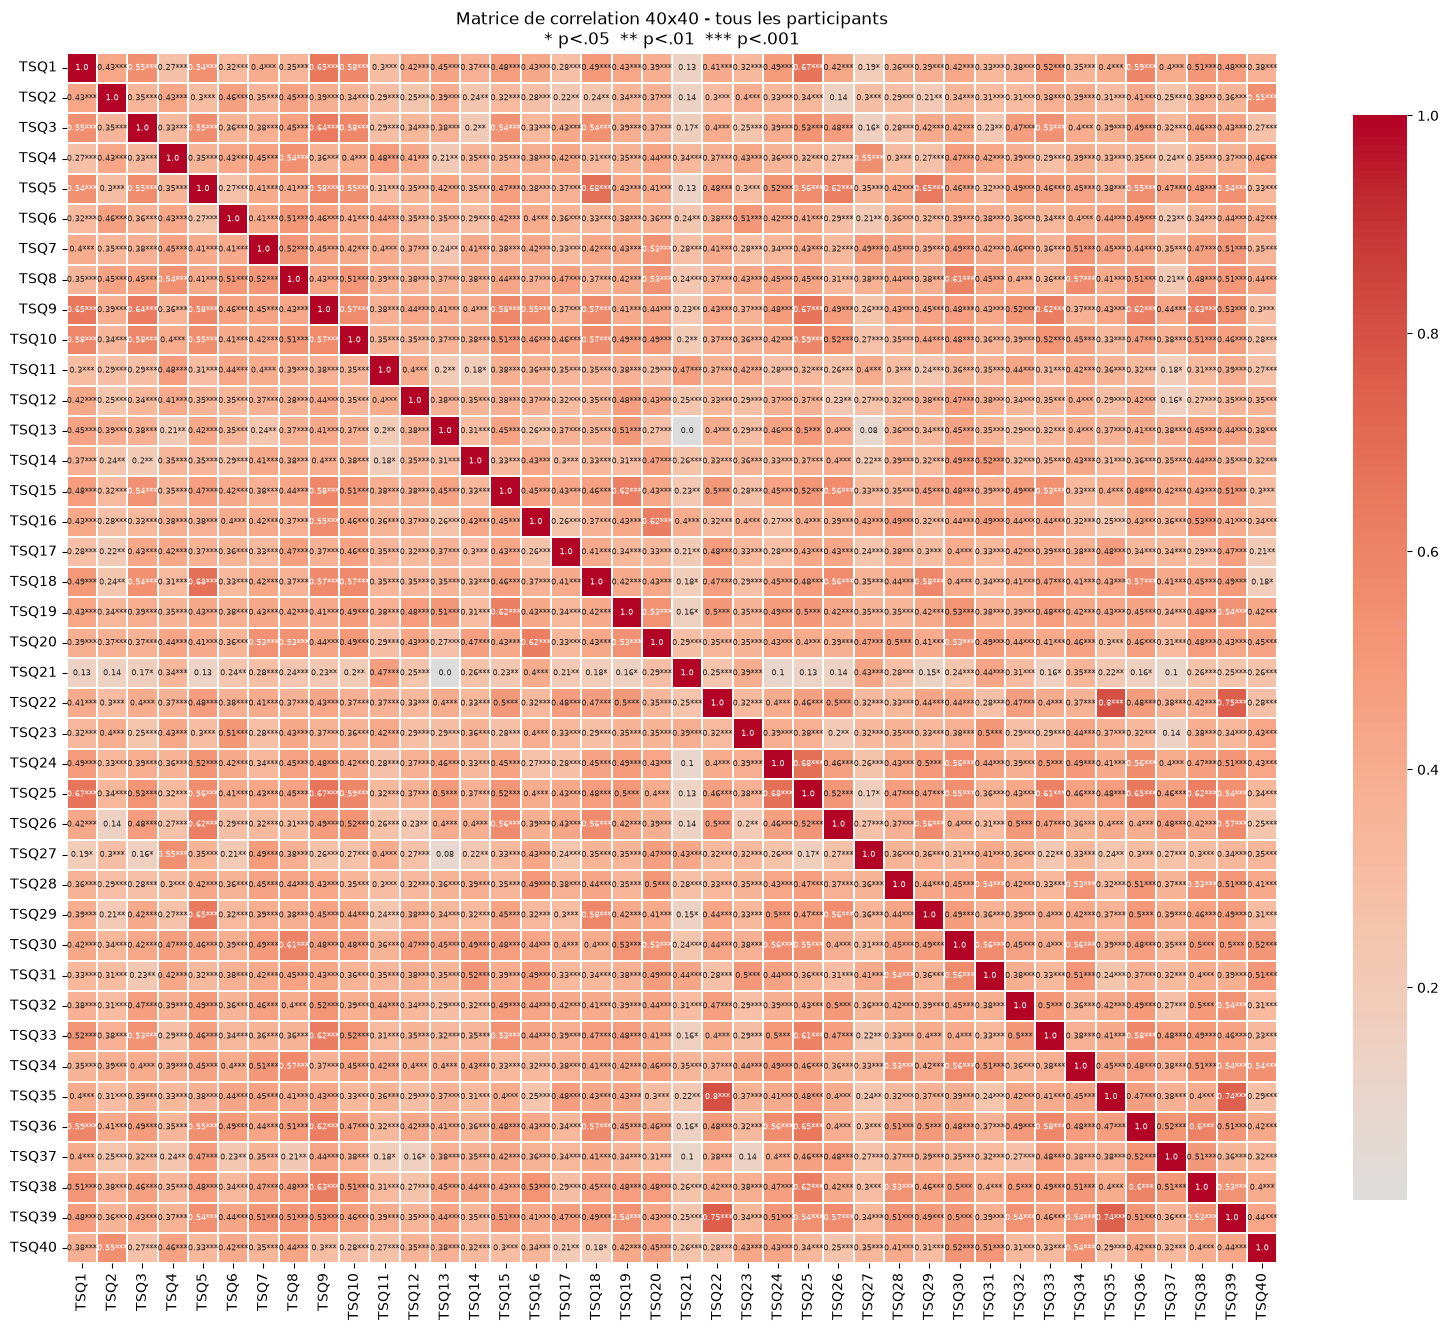

Items conservés : ['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']
Items retirés : ['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


In [33]:
from correl_TSQ import compute_tsq_corr

compute_tsq_corr(df_all, items=[f"TSQ{i}" for i in range(1, 41)], title="Matrice de correlation 40x40 - tous les participants")

from correl_TSQ import reduce_correlated_features
items = [f"TSQ{i}" for i in range(1, 41)]
selected_items = reduce_correlated_features(df_all, items, threshold=0.65)

print("Items conservés :", selected_items)
print("Items retirés :", [i for i in items if i not in selected_items])



# VIF pour voir la multicollinéarité

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_all[items].dropna()
vif_data = pd.DataFrame()
vif_data['item'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

     item       VIF
38  TSQ39  4.794701
21  TSQ22  4.555509
8    TSQ9  4.515037
34  TSQ35  4.411230
24  TSQ25  4.340604
35  TSQ36  3.555387
7    TSQ8  3.552024
29  TSQ30  3.527947
4    TSQ5  3.526071
37  TSQ38  3.231606
39  TSQ40  3.224609
25  TSQ26  3.155344
14  TSQ15  3.146901
17  TSQ18  3.104392
33  TSQ34  3.056742
2    TSQ3  3.055301
9   TSQ10  2.977464
31  TSQ32  2.954447
19  TSQ20  2.928316
23  TSQ24  2.909848
32  TSQ33  2.896184
18  TSQ19  2.875001
0    TSQ1  2.848724
30  TSQ31  2.793827
3    TSQ4  2.717808
26  TSQ27  2.502284
1    TSQ2  2.494486
27  TSQ28  2.482813
36  TSQ37  2.474727
5    TSQ6  2.456322
28  TSQ29  2.440229
15  TSQ16  2.436409
22  TSQ23  2.380565
16  TSQ17  2.262096
6    TSQ7  2.201363
11  TSQ12  2.181394
13  TSQ14  2.139214
12  TSQ13  2.130804
20  TSQ21  1.924337
10  TSQ11  1.752305


In [38]:
colonnes_a_exclure = ['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39', 'score_total']  
df_red_sains = df_TSQ.drop(columns=colonnes_a_exclure)
df_red_pd = df_TSQ_PD.drop(columns=colonnes_a_exclure)

# methodes de la silhouette score, du coude, indice de Davies-Bouldin, indice de Calinski-Harabasz pour déterminer combien de k doit on prendre pour le K-means (étape d'après)

k=2 | inertie=25824.0 | silhouette=0.314 | davies-bouldin=1.438 | calinski-harabasz=69.1
k=3 | inertie=23536.9 | silhouette=0.220 | davies-bouldin=2.135 | calinski-harabasz=45.0
k=4 | inertie=22146.4 | silhouette=0.152 | davies-bouldin=2.412 | calinski-harabasz=34.8
k=5 | inertie=21496.3 | silhouette=0.150 | davies-bouldin=2.481 | calinski-harabasz=27.8
k=6 | inertie=20985.4 | silhouette=0.151 | davies-bouldin=2.187 | calinski-harabasz=23.4
k=7 | inertie=20162.3 | silhouette=0.152 | davies-bouldin=2.401 | calinski-harabasz=21.1
k=8 | inertie=19715.9 | silhouette=0.155 | davies-bouldin=2.273 | calinski-harabasz=18.9
k=9 | inertie=19125.0 | silhouette=0.149 | davies-bouldin=2.200 | calinski-harabasz=17.5
k=10 | inertie=18851.2 | silhouette=0.150 | davies-bouldin=2.413 | calinski-harabasz=15.9


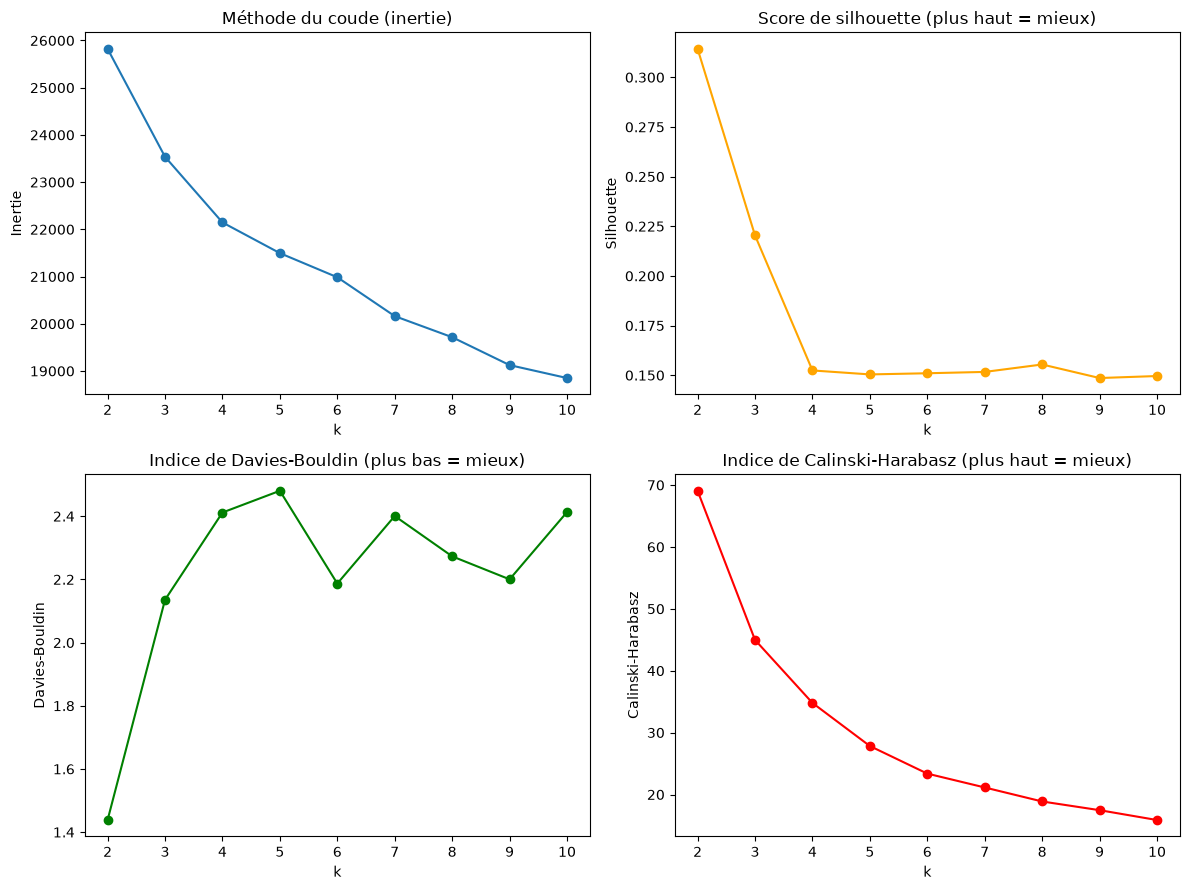


Meilleur k selon chaque indice :
  Silhouette (max)        : k=2 (score=0.314)
  Davies-Bouldin (min)    : k=2 (score=1.438)
  Calinski-Harabasz (max) : k=2 (score=69.1)


,k,inertie,silhouette,davies_bouldin,calinski_harabasz
0,2,25823.951890,0.314351,1.438359,69.068924
1,3,23536.919414,0.220403,2.135415,44.977000
2,4,22146.367268,0.152410,2.411765,34.795796
3,5,21496.336279,0.150412,2.480556,27.833162
4,6,20985.378839,0.150997,2.186971,23.376311
5,7,20162.316558,0.151669,2.400682,21.138616
6,8,19715.866767,0.155415,2.273058,18.875344
7,9,19125.012104,0.148590,2.200287,17.469517
8,10,18851.247550,0.149602,2.413265,15.877679


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np

X = df_red_sains.values  

k_values = range(2, 11)
inerties = []
silhouettes = []
davies_bouldin = []
calinski_harabasz = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    davies_bouldin.append(davies_bouldin_score(X, labels))
    calinski_harabasz.append(calinski_harabasz_score(X, labels))

    print(f"k={k} | inertie={kmeans.inertia_:.1f} | silhouette={silhouettes[-1]:.3f} "
          f"| davies-bouldin={davies_bouldin[-1]:.3f} | calinski-harabasz={calinski_harabasz[-1]:.1f}")

# Récapitulatif dans un tableau
resultats_k = pd.DataFrame({
    "k": list(k_values),
    "inertie": inerties,
    "silhouette": silhouettes,
    "davies_bouldin": davies_bouldin,
    "calinski_harabasz": calinski_harabasz,
})

# Visualisation des 4 indices côte à côte
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(k_values, inerties, marker="o")
axes[0, 0].set_title("Méthode du coude (inertie)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertie")

axes[0, 1].plot(k_values, silhouettes, marker="o", color="orange")
axes[0, 1].set_title("Score de silhouette (plus haut = mieux)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Silhouette")

axes[1, 0].plot(k_values, davies_bouldin, marker="o", color="green")
axes[1, 0].set_title("Indice de Davies-Bouldin (plus bas = mieux)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Davies-Bouldin")

axes[1, 1].plot(k_values, calinski_harabasz, marker="o", color="red")
axes[1, 1].set_title("Indice de Calinski-Harabasz (plus haut = mieux)")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Calinski-Harabasz")

for ax in axes.flat:
    ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

# Meilleur k selon chaque indice
print("\nMeilleur k selon chaque indice :")
print(f"  Silhouette (max)        : k={resultats_k.loc[resultats_k['silhouette'].idxmax(), 'k']} "
      f"(score={resultats_k['silhouette'].max():.3f})")
print(f"  Davies-Bouldin (min)    : k={resultats_k.loc[resultats_k['davies_bouldin'].idxmin(), 'k']} "
      f"(score={resultats_k['davies_bouldin'].min():.3f})")
print(f"  Calinski-Harabasz (max) : k={resultats_k.loc[resultats_k['calinski_harabasz'].idxmax(), 'k']} "
      f"(score={resultats_k['calinski_harabasz'].max():.1f})")

resultats_k

Donc on va prendre k = 2 pour le clustering

# UMAP sur tous les participants sains sur le df reduit 

In [ ]:
from umap_clustering import run_umap_clustering

result = run_umap_clustering(
    df_red_sains,
    n_clusters=2,
    random_state=42,
    group=group,
)


df_clust = result.df_clust         
clusters = result.clusters          
proj_2d = result.proj_2d            
proj_3d = result.proj_3d            
fig_2d, fig_3d = result.fig_2d, result.fig_3d

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    98
1    56
Name: count, dtype: int64
Cluster 0: 98 participants (group 0: 98)
Cluster 1: 56 participants (group 0: 56)


# Split train/test des participants sains + entrainement des modeles classifier (4 différents) sur le train et test pour voir si l'algo me classe bien dans le bon cluster (par rapport au UMAP) les participants. Grid search pour trouver le meilleur modele

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    98
1    56
Name: count, dtype: int64
Cluster 0: 98 participants (group 0: 98)
Cluster 1: 56 participants (group 0: 56)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.962 ±  0.047
Score sur test set : 0.964


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

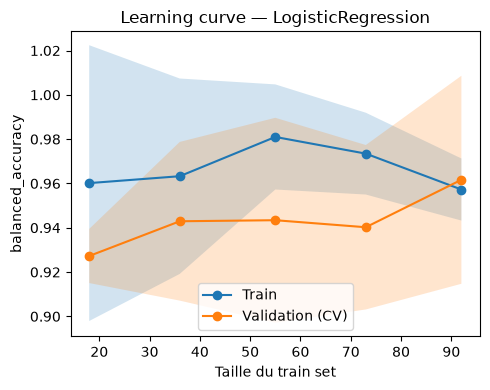


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.01}
Meilleur score CV : 0.955 ±  0.032
Score sur test set : 0.964


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

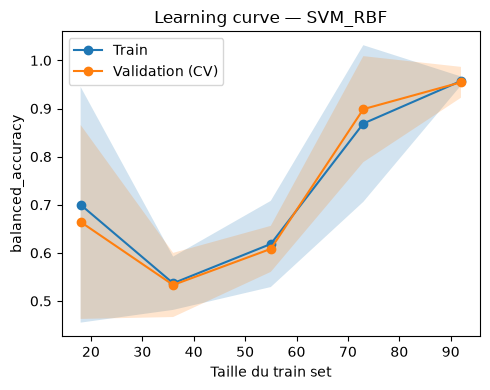


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.943 ±  0.037
Score sur test set : 0.964


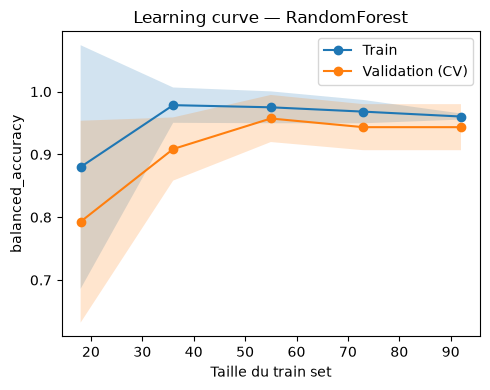


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.943 ±  0.037
Score sur test set : 0.909


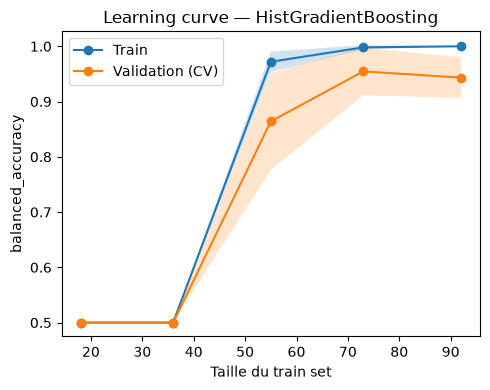


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.961667  0.046949    0.964286
SVM_RBF               0.954524  0.032051    0.964286
RandomForest          0.943413  0.036659    0.964286
HistGradientBoosting  0.943413  0.036659    0.908571

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.93      0.96        14

    accuracy                           0.97        39
   macro avg       0.98      0.96      0.97        39
weighted avg       0.98      0.97      0.97        39



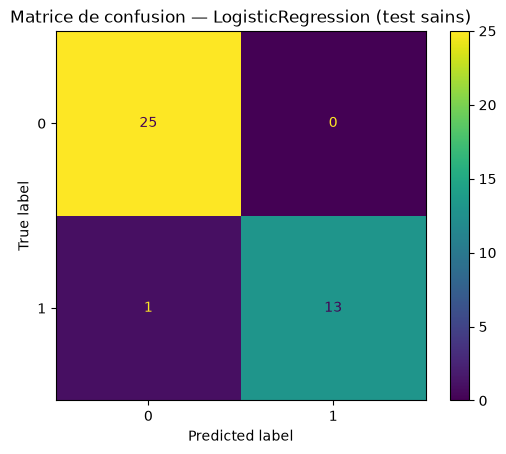

In [ ]:
from sklearn.model_selection import train_test_split
from umap_clustering import run_umap_clustering
from machinelearning import train_and_compare_classifiers, apply_to_patients

# resultat du umap
result = run_umap_clustering(
    df_red_sains, n_clusters=2, random_state=42, group=group, show=False,
)

# reprend les resultats umap pour voir ou sont repartis les participants cluster 0 ou 1
X_all = result.proj_2d
y_all = result.clusters

# Split train/test SUR les projections/labels déjà calculés 
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.25,
    random_state=42,
    stratify=y_all,  # garde la proportion des clusters
)

# Entraîne et compare les classifieurs
results, summary, best_model_name, best_model = train_and_compare_classifiers(
    X_train, y_train, X_test, y_test, scoring="balanced_accuracy"
)

Clairement overfit 

# Réprésentation de la prédiction de la répartition des patients sur les clusters 0 ou 1 dans l'espace UMAP des participants sains

In [ ]:
X_patients_2d = result.umap_2d_model.transform(df_red_pd.values) #  Projete les patients dans l'espace UMAP appris sur les sains (transform, pas fit)

y_pred_patients = best_model.predict(X_patients_2d) # Applique le best modèle de classif pour prédire leur "cluster" 

df_patients_clust = df_red_pd.copy()
df_patients_clust['cluster_pred'] = y_pred_patients

print(df_patients_clust['cluster_pred'].value_counts().sort_index())

cluster_pred
0    13
1    18
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_all = result.proj_2d
y_all = result.clusters
idx_all = df_red_sains.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, idx_all,
    test_size=0.25,
    random_state=42,
    stratify=y_all,
)


X_patients_umap = result.umap_2d_model.transform(df_red_pd.values)

import plotly.express as px

hover_train = [f"Participant {i}" for i in idx_train]
hover_test  = [f"Participant {i}" for i in idx_test]
hover_diag  = [f"Participant {i}" for i in df_red_pd.index]

df_plot = pd.concat([
    pd.DataFrame({
        "x": X_train[:, 0], "y": X_train[:, 1],
        "cluster": y_train.astype(str),
        "type": "Sains (train)",
        "participant": hover_train,
    }),
    pd.DataFrame({
        "x": X_test[:, 0], "y": X_test[:, 1],
        "cluster": y_test.astype(str),
        "type": "Sains (test)",
        "participant": hover_test,
    }),
    pd.DataFrame({
        "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
        "cluster": df_patients_clust['cluster_pred'].astype(str),
        "type": "Diag",
        "participant": hover_diag,
    }),
], ignore_index=True)

fig = px.scatter(
    df_plot, x="x", y="y",
    color="cluster", symbol="type",
    color_discrete_map={"0": '#FC6955', "1": "#A777F1" },
    symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
    opacity=0.7,
    hover_name="participant",
    title="Patients projetés dans l'espace UMAP crée sur les participants sains",
)

for trace in fig.data:
    if "Diag" in trace.name:
        trace.marker.line = dict(width=1, color="black")

fig.show(renderer="browser")

# 2 ème analyse
* creation de chaque df pour chaque groupes d'items
* UMAP + Clustering sur participants sains pour chaque df 
* ajouter à la boucle : Split train/test des participants sains + Classifier (4 modeles) avec GridSearch pour chaque df
* visualisation du best model sur le groupe de participants diag

In [ ]:
#Core items

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15','TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31','TSQ34','TSQ40']
items_core_md = ['TSQ9','TSQ14','TSQ17','TSQ25','TSQ28','TSQ29','TSQ36']
items_core_ma = ['TSQ22','TSQ32','TSQ35','TSQ39']
items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20','TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']
items_core_pt = ['TSQ2','TSQ3','TSQ5','TSQ6','TSQ17','TSQ18','TSQ26','TSQ30','TSQ37']

#Periphery items
items_per_sz = ['TSQ1','TSQ3','TSQ5','TSQ6','TSQ13','TSQ14','TSQ23','TSQ27','TSQ35','TSQ38','TSQ39']
items_per_md = ['TSQ1','TSQ2','TSQ8','TSQ12','TSQ16','TSQ18','TSQ19','TSQ20','TSQ23','TSQ27','TSQ31']
items_per_ma = ['TSQ3','TSQ7','TSQ9','TSQ19','TSQ21','TSQ30','TSQ34','TSQ37','TSQ38']
items_per_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27','TSQ32']
items_per_pt = ['TSQ1','TSQ9','TSQ12','TSQ13','TSQ14','TSQ16','TSQ19','TSQ20','TSQ23','TSQ24','TSQ25','TSQ27','TSQ28','TSQ31','TSQ33','TSQ35','TSQ36','TSQ38','TSQ39','TSQ40']

#Combined Core+Periphery items 
items_tot_sz = items_core_sz + items_per_sz
items_tot_md = items_core_md + items_per_md
items_tot_ma = items_core_ma + items_per_ma
items_tot_an = items_core_an + items_per_an
items_tot_pt = items_core_pt + items_per_pt

## A SUPPRIMER??

In [ ]:
# --- Core items ---
df_core_ax   = df_all[items_core_an].copy()
df_core_sz   = df_all[items_core_sz].copy()
df_core_mdd  = df_all[items_core_md].copy()
df_core_man  = df_all[items_core_ma].copy()
df_core_ptsd = df_all[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_all[items_per_an].copy()
df_periph_sz   = df_all[items_per_sz].copy()
df_periph_mdd  = df_all[items_per_md].copy()
df_periph_man  = df_all[items_per_ma].copy()
df_periph_ptsd = df_all[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_all[items_tot_an].copy()
df_tot_sz   = df_all[items_tot_sz].copy()
df_tot_mdd  = df_all[items_tot_md].copy()
df_tot_man  = df_all[items_tot_ma].copy()
df_tot_ptsd = df_all[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}

In [ ]:
# --- Core items ---
df_core_ax   = df_TSQ[items_core_an].copy()
df_core_sz   = df_TSQ[items_core_sz].copy()
df_core_mdd  = df_TSQ[items_core_md].copy()
df_core_man  = df_TSQ[items_core_ma].copy()
df_core_ptsd = df_TSQ[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_TSQ[items_per_an].copy()
df_periph_sz   = df_TSQ[items_per_sz].copy()
df_periph_mdd  = df_TSQ[items_per_md].copy()
df_periph_man  = df_TSQ[items_per_ma].copy()
df_periph_ptsd = df_TSQ[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_TSQ[items_tot_an].copy()
df_tot_sz   = df_TSQ[items_tot_sz].copy()
df_tot_mdd  = df_TSQ[items_tot_md].copy()
df_tot_man  = df_TSQ[items_tot_ma].copy()
df_tot_ptsd = df_TSQ[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}
# --- Core items ---
df_core_ax_PD   = df_TSQ_PD[items_core_an].copy()
df_core_sz_PD   = df_TSQ_PD[items_core_sz].copy()
df_core_mdd_PD  = df_TSQ_PD[items_core_md].copy()
df_core_man_PD  = df_TSQ_PD[items_core_ma].copy()
df_core_ptsd_PD = df_TSQ_PD[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax_PD   = df_TSQ_PD[items_per_an].copy()
df_periph_sz_PD   = df_TSQ_PD[items_per_sz].copy()
df_periph_mdd_PD  = df_TSQ_PD[items_per_md].copy()
df_periph_man_PD  = df_TSQ_PD[items_per_ma].copy()
df_periph_ptsd_PD = df_TSQ_PD[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax_PD   = df_TSQ_PD[items_tot_an].copy()
df_tot_sz_PD   = df_TSQ_PD[items_tot_sz].copy()
df_tot_mdd_PD  = df_TSQ_PD[items_tot_md].copy()
df_tot_man_PD  = df_TSQ_PD[items_tot_ma].copy()
df_tot_ptsd_PD = df_TSQ_PD[items_tot_pt].copy()

#dico
sous_echelles_PD = {
    "core_ax_PD": df_core_ax_PD, "core_sz_PD": df_core_sz_PD, "core_mdd_PD": df_core_mdd_PD,
    "core_man_PD": df_core_man_PD, "core_ptsd_PD": df_core_ptsd_PD,
    "periph_ax_PD": df_periph_ax_PD, "periph_sz_PD": df_periph_sz_PD, "periph_mdd_PD": df_periph_mdd_PD,
    "periph_man_PD": df_periph_man_PD, "periph_ptsd_PD": df_periph_ptsd_PD,
}


========================= core_ax =========================


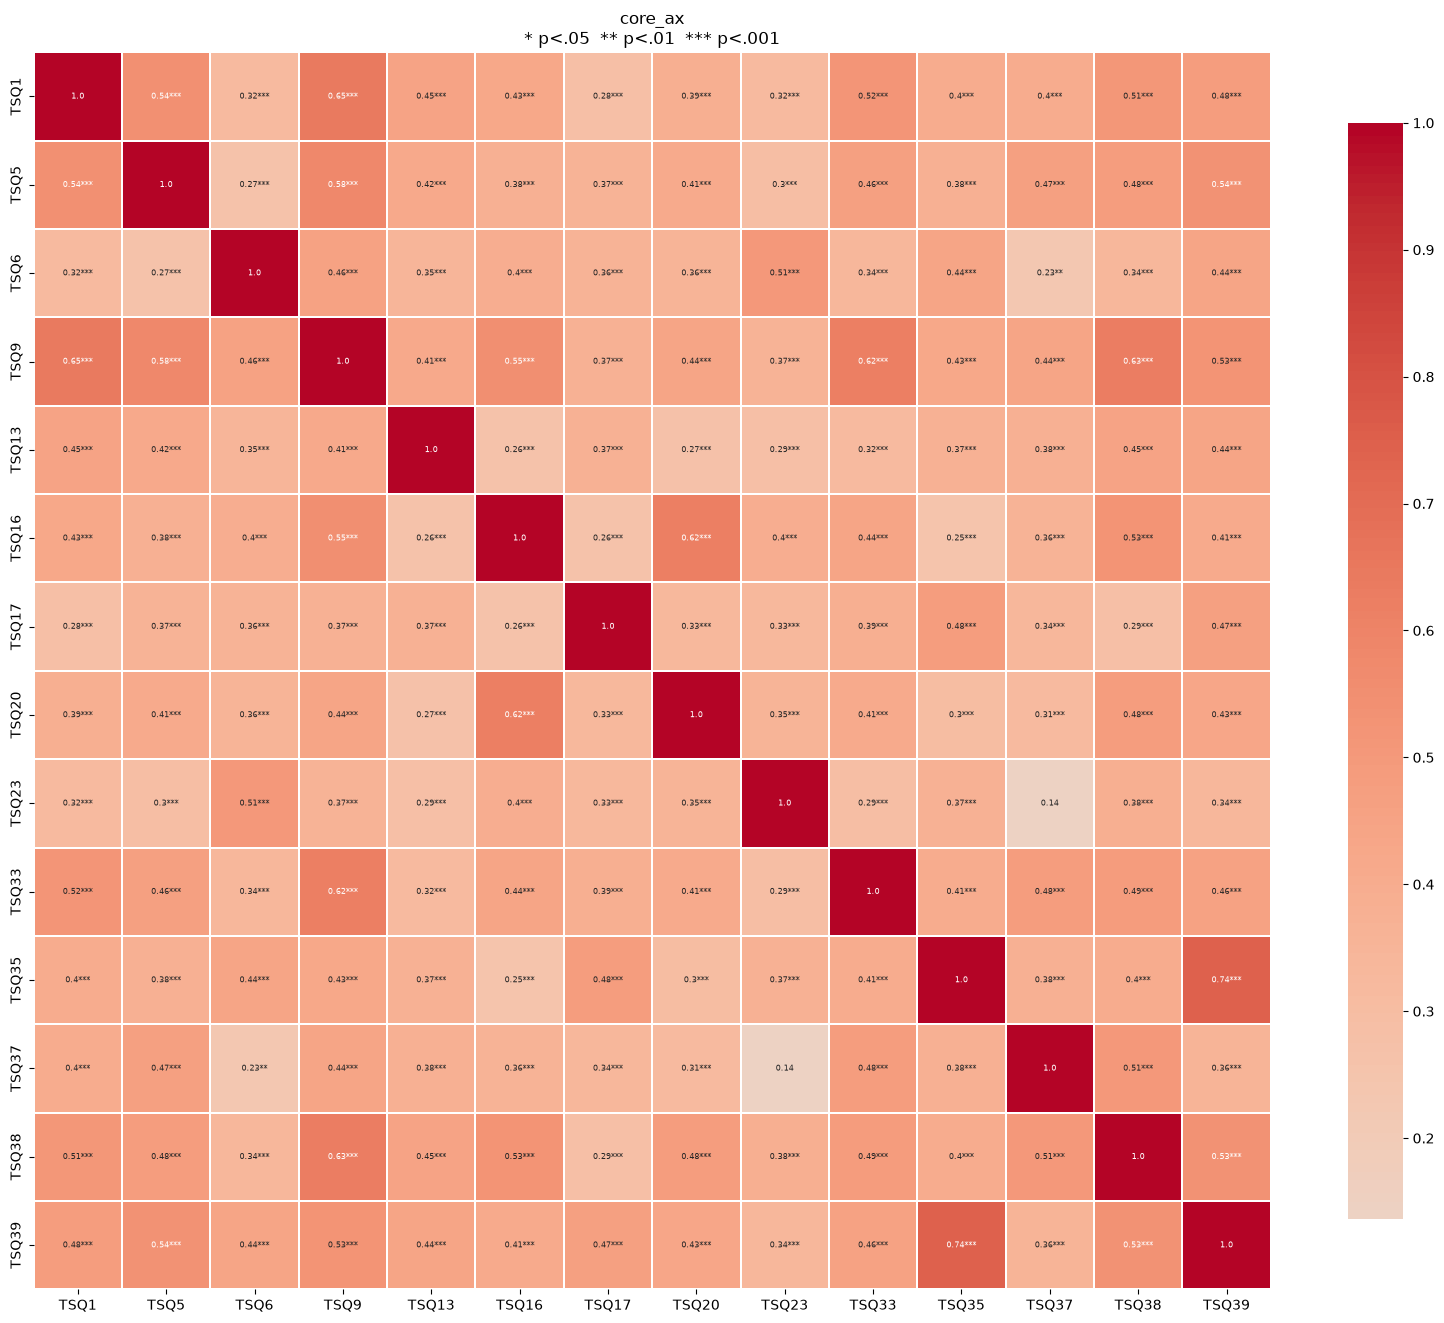

Items conservés (12/14) : ['TSQ1', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ16', 'TSQ17', 'TSQ20', 'TSQ23', 'TSQ33', 'TSQ35', 'TSQ37', 'TSQ38']
Items retirés (2) : ['TSQ9', 'TSQ39']

========================= core_sz =========================


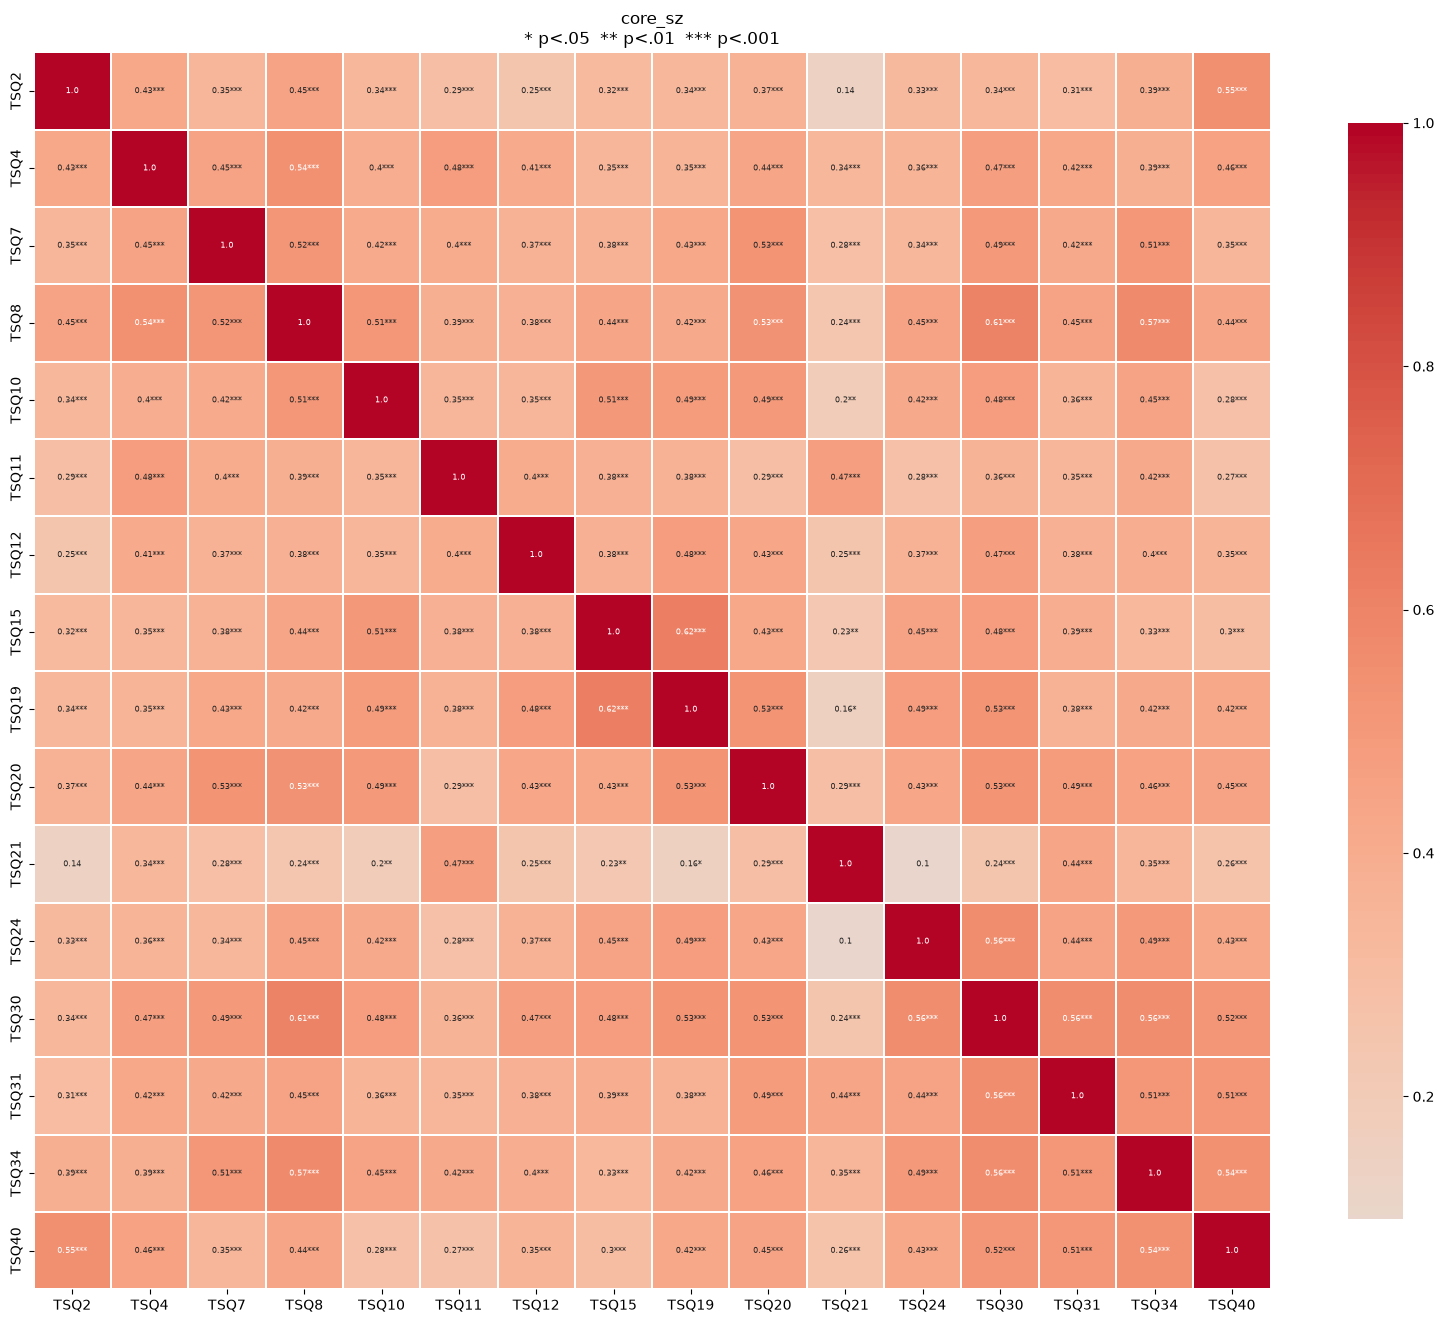

Items conservés (16/16) : ['TSQ2', 'TSQ4', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ15', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ24', 'TSQ30', 'TSQ31', 'TSQ34', 'TSQ40']
Items retirés (0) : []

========================= core_mdd =========================


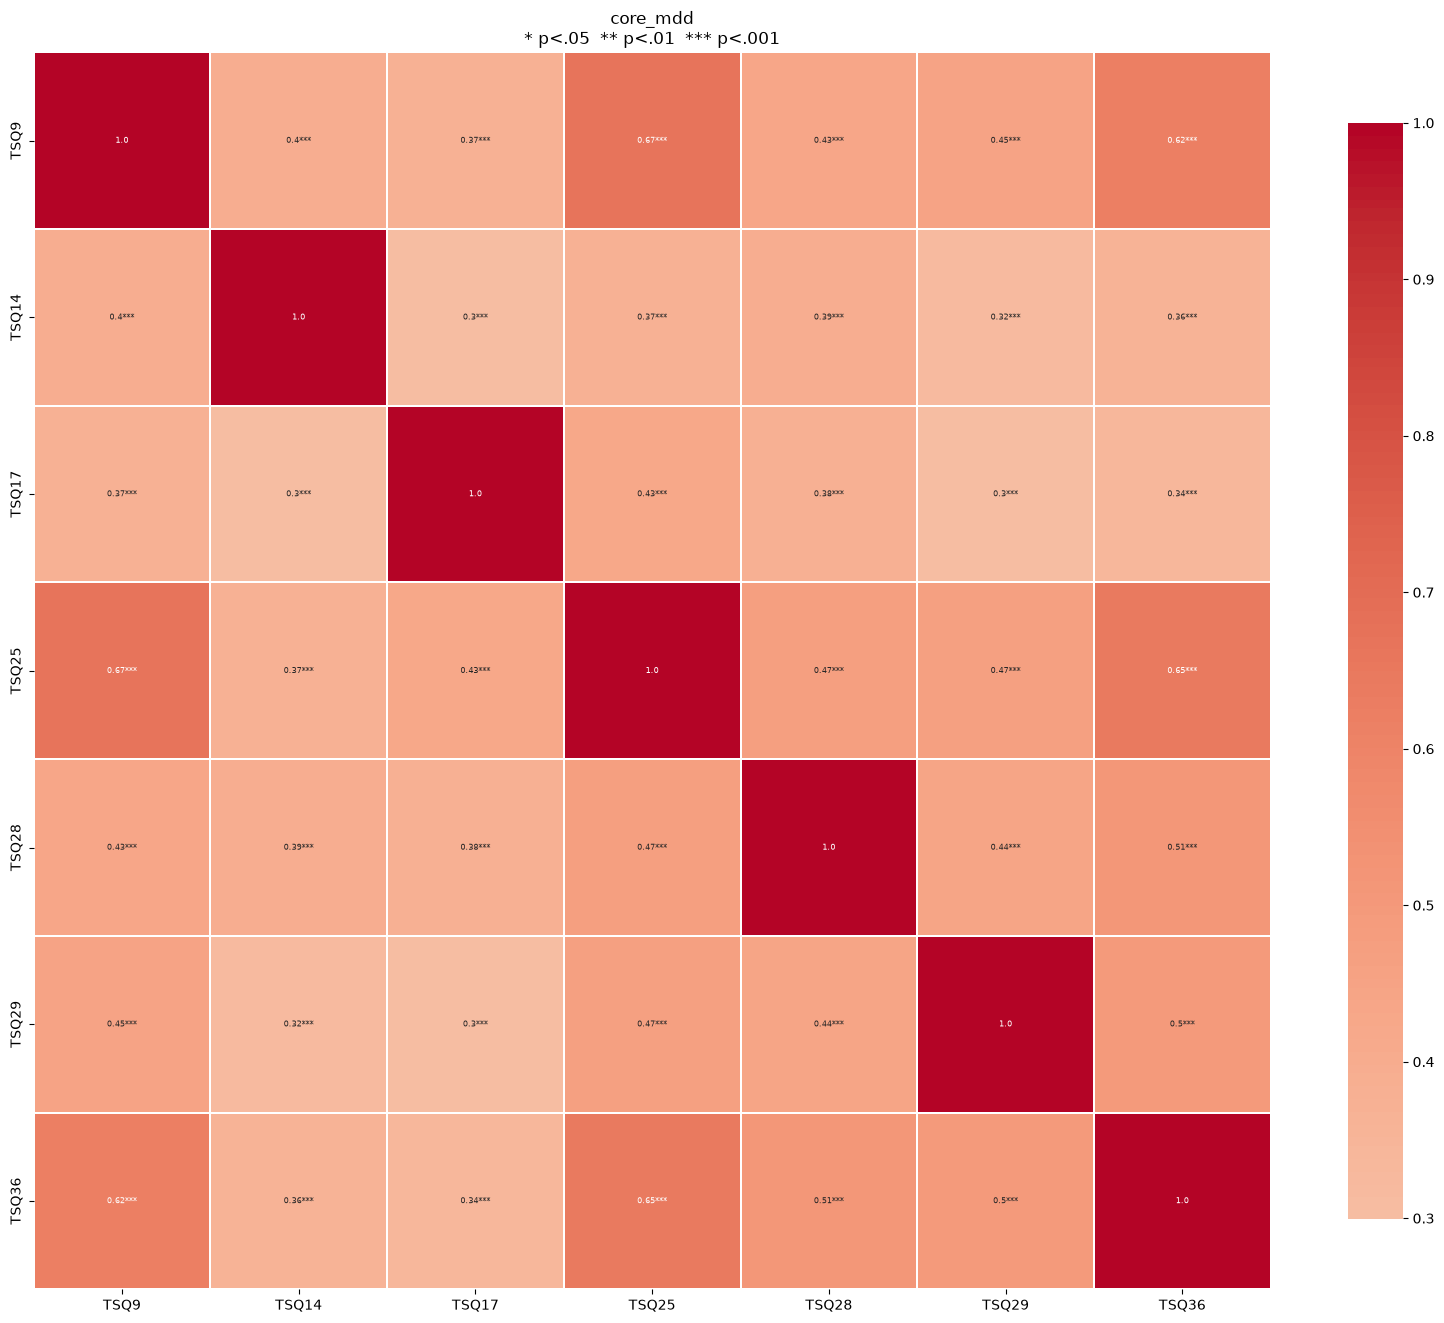

Items conservés (6/7) : ['TSQ9', 'TSQ14', 'TSQ17', 'TSQ28', 'TSQ29', 'TSQ36']
Items retirés (1) : ['TSQ25']

========================= core_man =========================


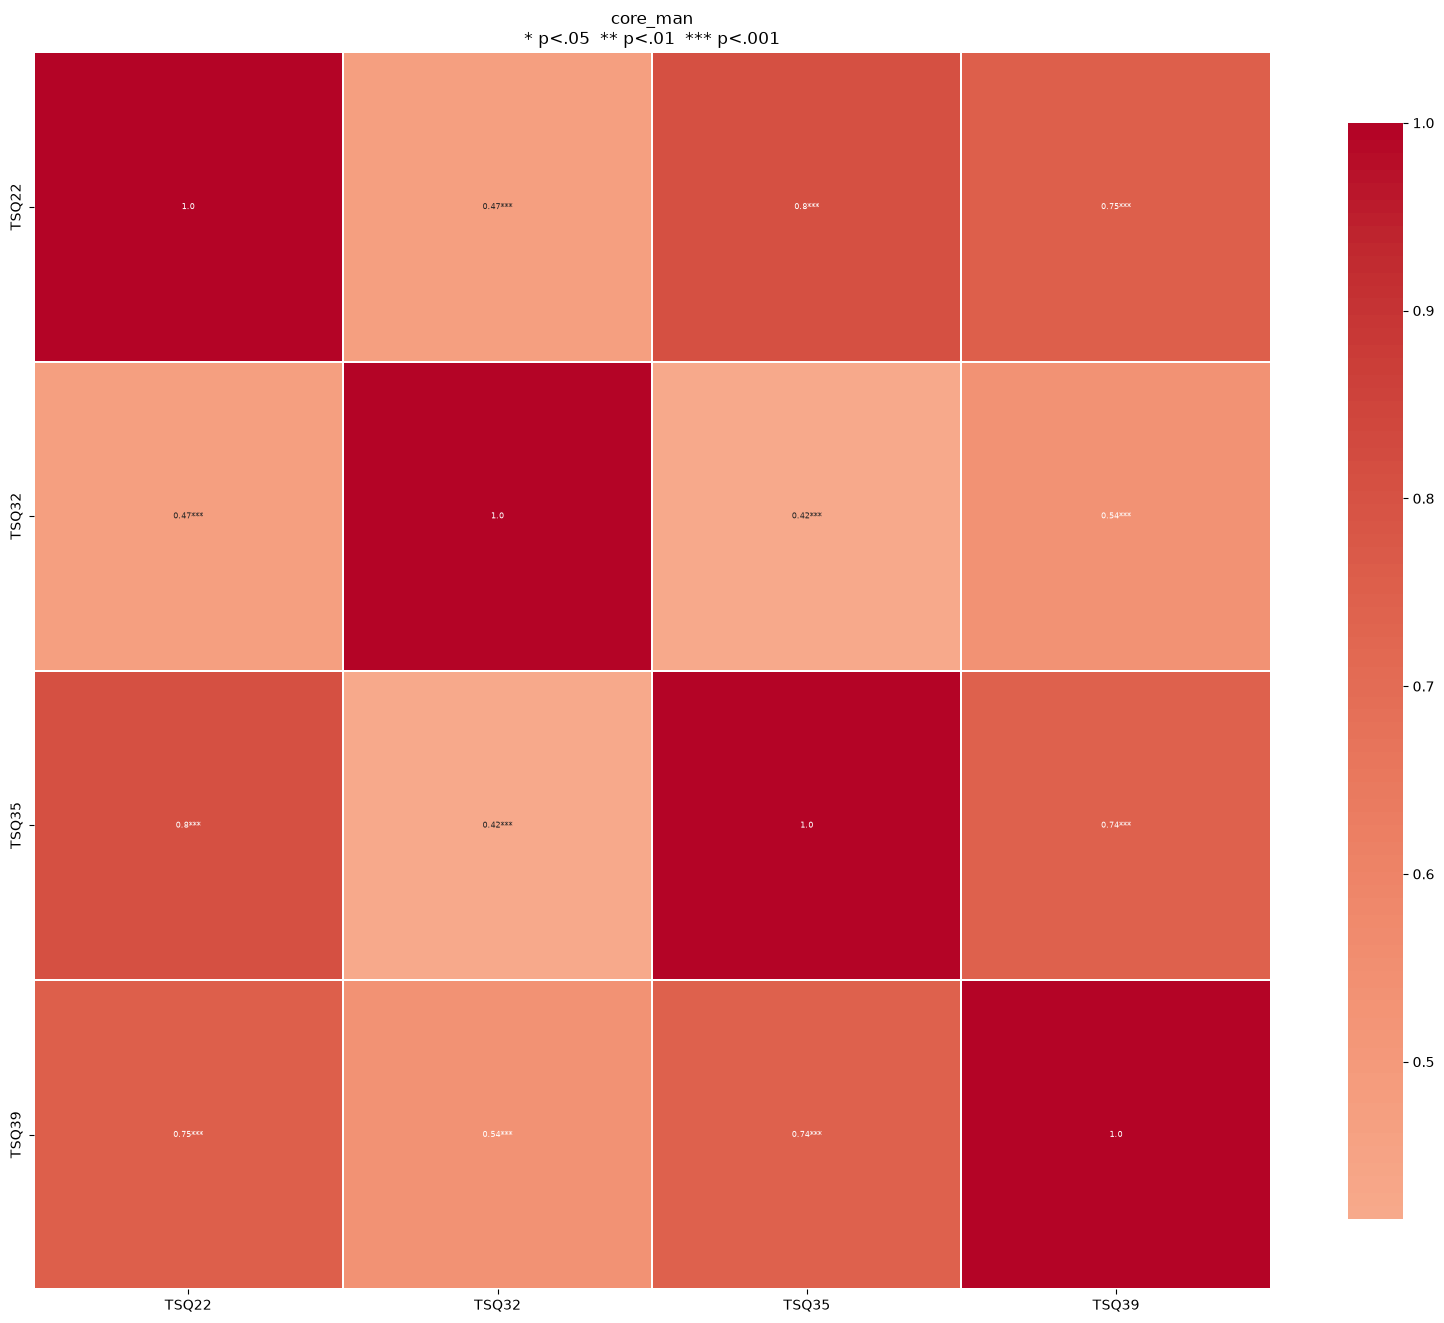

Items conservés (2/4) : ['TSQ32', 'TSQ35']
Items retirés (2) : ['TSQ22', 'TSQ39']

========================= core_ptsd =========================


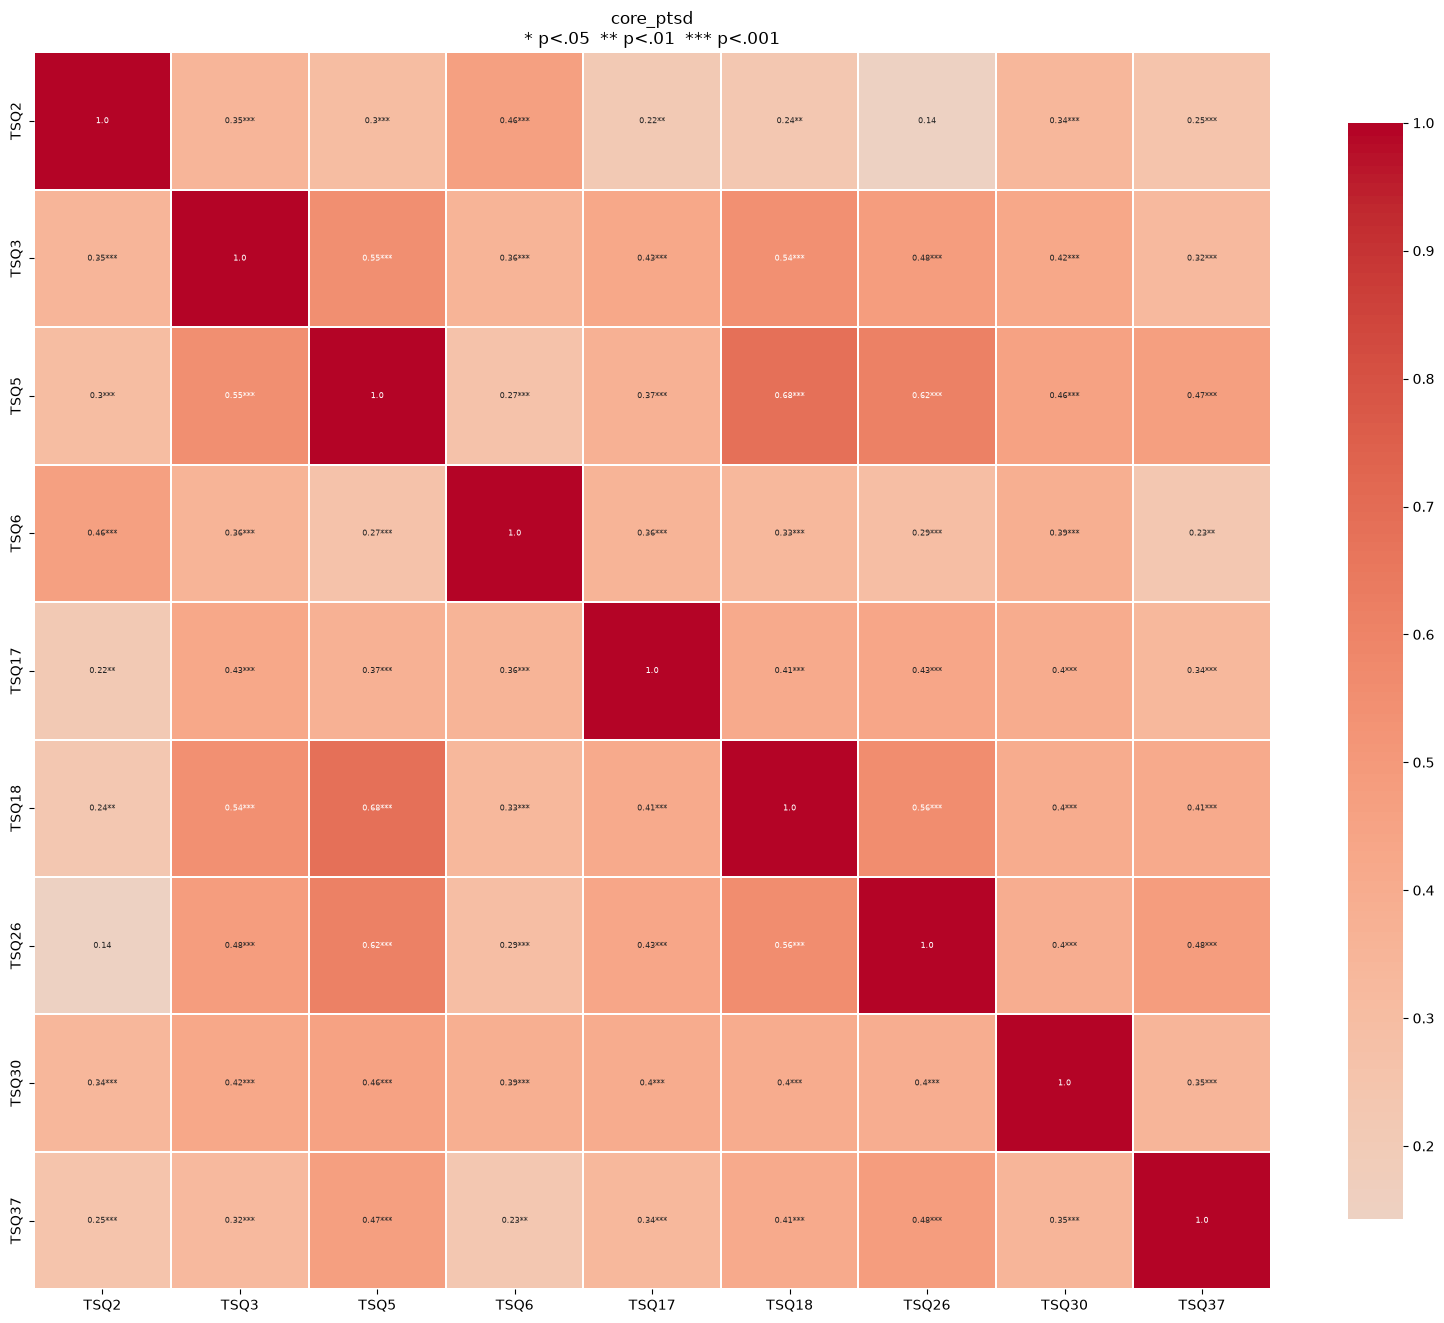

Items conservés (8/9) : ['TSQ2', 'TSQ3', 'TSQ6', 'TSQ17', 'TSQ18', 'TSQ26', 'TSQ30', 'TSQ37']
Items retirés (1) : ['TSQ5']

========================= periph_ax =========================


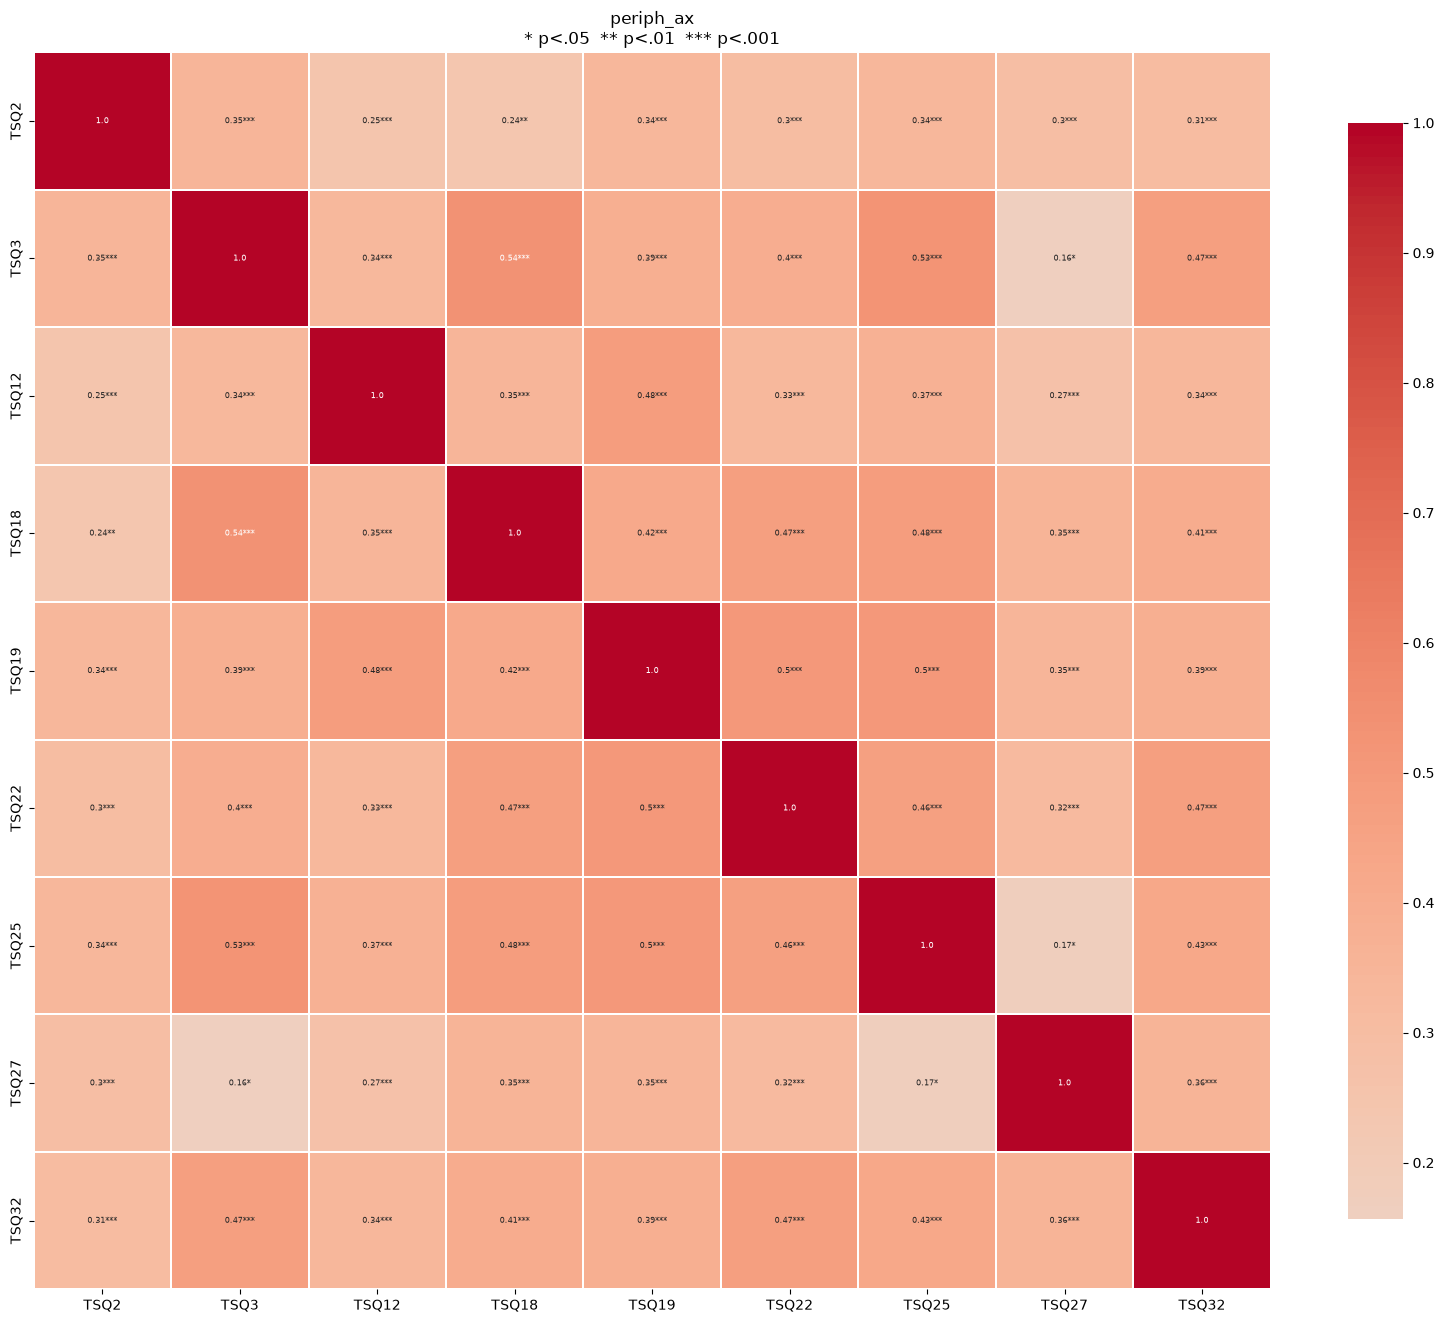

Items conservés (9/9) : ['TSQ2', 'TSQ3', 'TSQ12', 'TSQ18', 'TSQ19', 'TSQ22', 'TSQ25', 'TSQ27', 'TSQ32']
Items retirés (0) : []

========================= periph_sz =========================


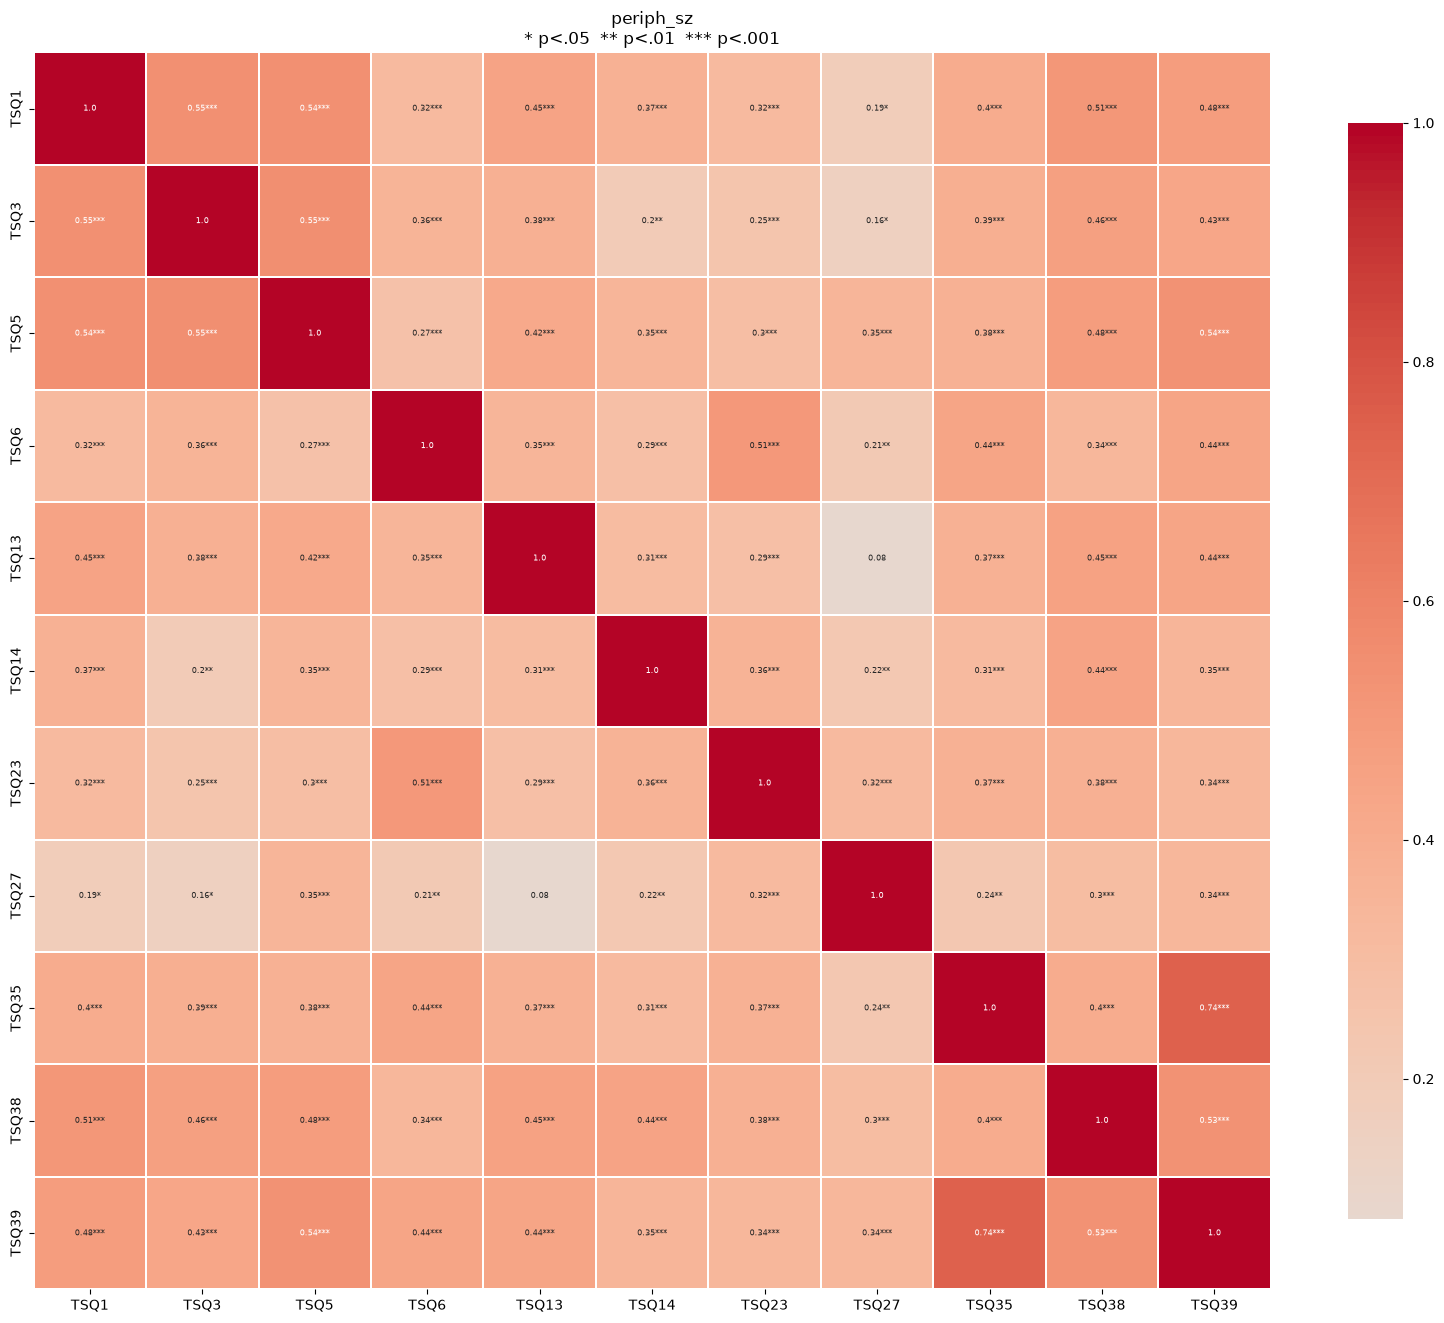

Items conservés (10/11) : ['TSQ1', 'TSQ3', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ14', 'TSQ23', 'TSQ27', 'TSQ35', 'TSQ38']
Items retirés (1) : ['TSQ39']

========================= periph_mdd =========================


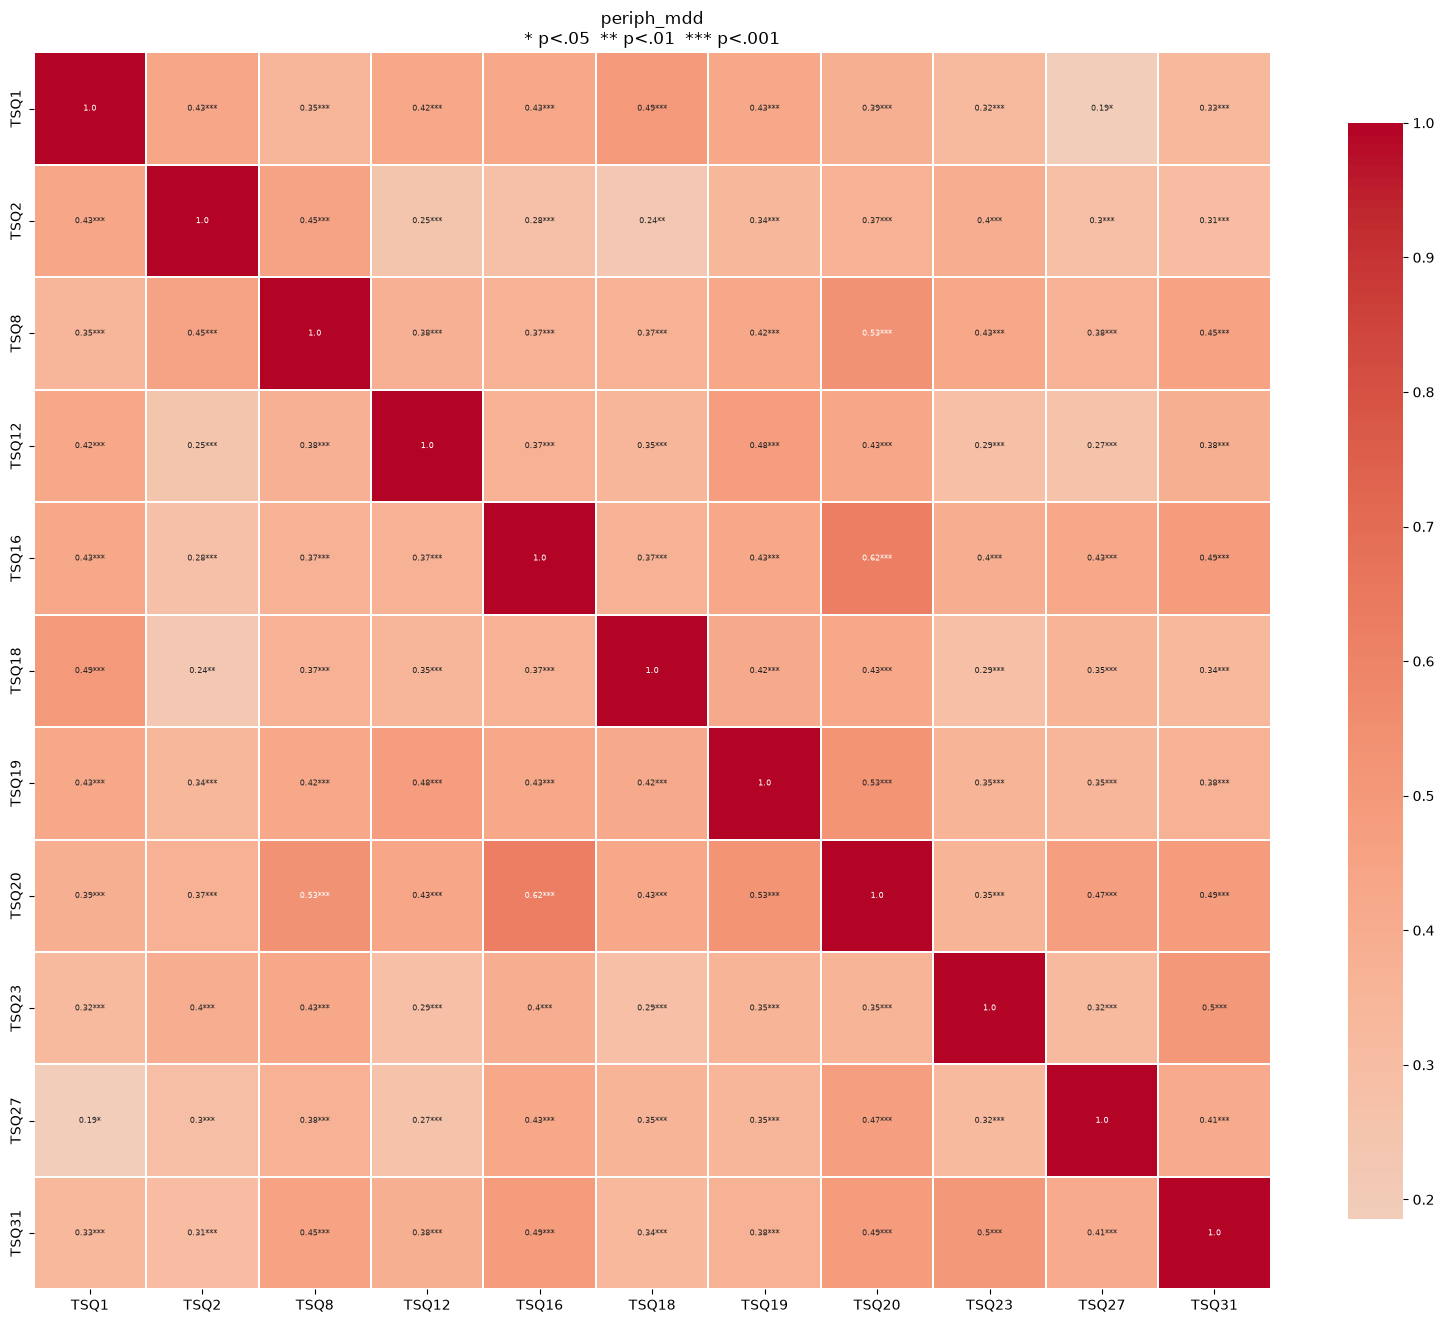

Items conservés (11/11) : ['TSQ1', 'TSQ2', 'TSQ8', 'TSQ12', 'TSQ16', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ27', 'TSQ31']
Items retirés (0) : []

========================= periph_man =========================


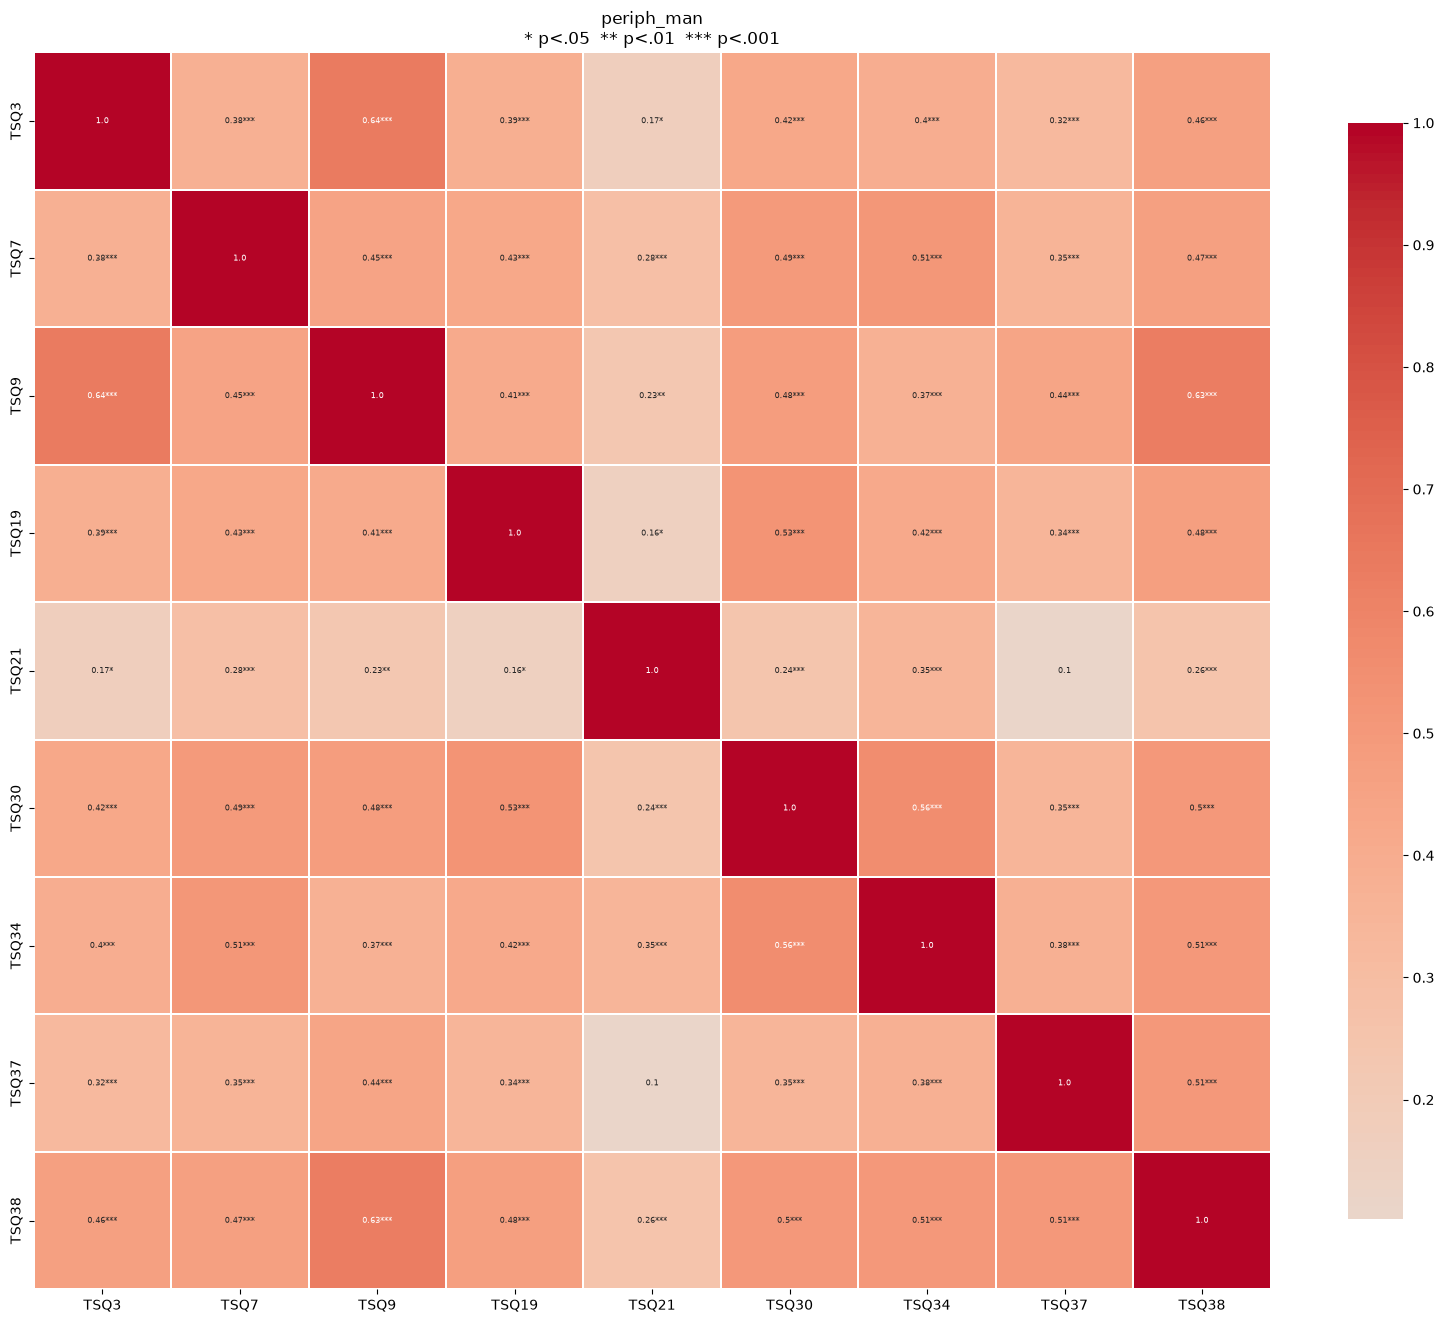

Items conservés (9/9) : ['TSQ3', 'TSQ7', 'TSQ9', 'TSQ19', 'TSQ21', 'TSQ30', 'TSQ34', 'TSQ37', 'TSQ38']
Items retirés (0) : []

========================= periph_ptsd =========================


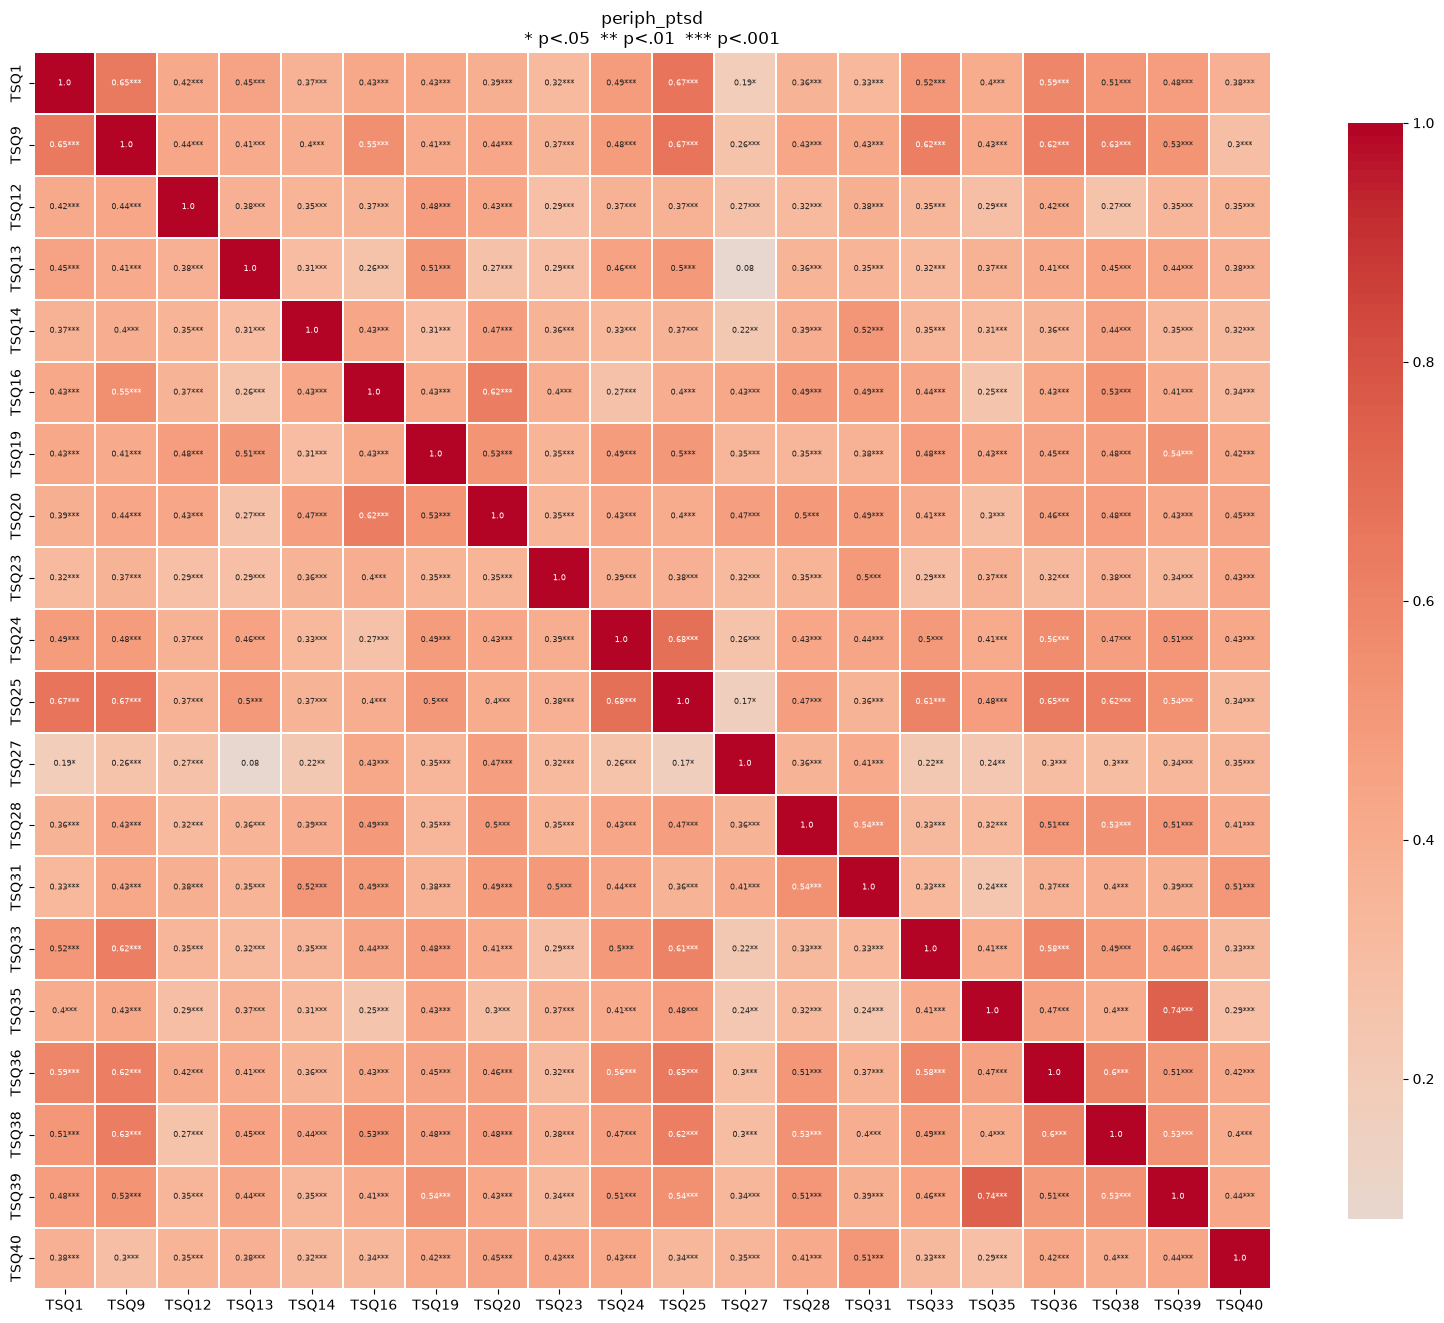

Items conservés (17/20) : ['TSQ1', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ16', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ24', 'TSQ27', 'TSQ28', 'TSQ31', 'TSQ33', 'TSQ35', 'TSQ36', 'TSQ38', 'TSQ40']
Items retirés (3) : ['TSQ9', 'TSQ25', 'TSQ39']


In [ ]:
from correl_TSQ import compute_tsq_corr, reduce_correlated_features

resultats_corr = {}

for nom, df_subset in sous_echelles.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    items = list(df_subset.columns)

    # Matrice de corrélation + heatmap pour chq sous-échelle
    compute_tsq_corr(df_all, items=items, title=nom)

    # greedy glouton pour enlever les items redondants qui covarient le + entre eux, pour chq sous echelle
    selected_items = reduce_correlated_features(df_all, items, threshold=0.65)
    dropped_items = [i for i in items if i not in selected_items]

    print(f"Items à conserver ({len(selected_items)}/{len(items)}) :", selected_items)
    print(f"Items à retirer ({len(dropped_items)}) :", dropped_items)

    resultats_corr[nom] = {
        "items_initiaux": items,
        "selected_items": selected_items,
        "dropped_items": dropped_items,
    }

In [ ]:
sous_echelles_red = {}
sous_echelles_PD_red = {}

for nom, df_sains in sous_echelles.items():
    dropped = resultats_corr[nom]["dropped_items"] + ["score_total"]

    df_sains_red = df_sains.drop(columns=dropped, errors="ignore")
    df_pd_red = sous_echelles_PD[f"{nom}_PD"].drop(columns=dropped, errors="ignore")

    sous_echelles_red[nom] = df_sains_red
    sous_echelles_PD_red[f"{nom}_PD"] = df_pd_red

    print(f"{nom}: {df_sains.shape[1]} → {df_sains_red.shape[1]} items "
          f"(retirés: {dropped if dropped else 'aucun'})")

core_ax: 14 → 12 items (retirés: ['TSQ9', 'TSQ39', 'score_total'])
core_sz: 16 → 16 items (retirés: ['score_total'])
core_mdd: 7 → 6 items (retirés: ['TSQ25', 'score_total'])
core_man: 4 → 2 items (retirés: ['TSQ22', 'TSQ39', 'score_total'])
core_ptsd: 9 → 8 items (retirés: ['TSQ5', 'score_total'])
periph_ax: 9 → 9 items (retirés: ['score_total'])
periph_sz: 11 → 10 items (retirés: ['TSQ39', 'score_total'])
periph_mdd: 11 → 11 items (retirés: ['score_total'])
periph_man: 9 → 9 items (retirés: ['score_total'])
periph_ptsd: 20 → 17 items (retirés: ['TSQ9', 'TSQ25', 'TSQ39', 'score_total'])


# Boucle sur chaque sous echelle : 
* UMAP sur participants sains +
*  clustering (2 groupes) + 
* train/test sur classifier 
* --> best model à tester sur les participants avec diag --> voir ou sont classés la pop diag concernée par rapport aux sains et aux autres patho

* ex: patients depressifs sont-ils dans le meme cluster/ le + symptomato pour le df core depression? 

In [ ]:
# Entraîne et compare les classifieurs
results, summary, best_model_name, best_model = train_and_compare_classifiers(
    X_train, y_train, X_test, y_test, scoring="balanced_accuracy"
)


========================= core_ax =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    68
1    86
Name: count, dtype: int64
Cluster 0: 68 participants (group 0: 68)
Cluster 1: 86 participants (group 0: 86)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.9 ±  0.069
Score sur test set : 0.912


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

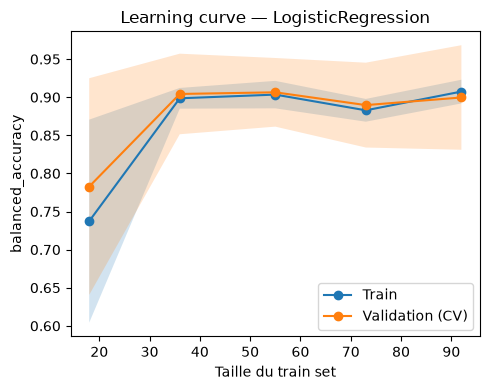


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 'scale'}
Meilleur score CV : 0.907 ±  0.061
Score sur test set : 0.941


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

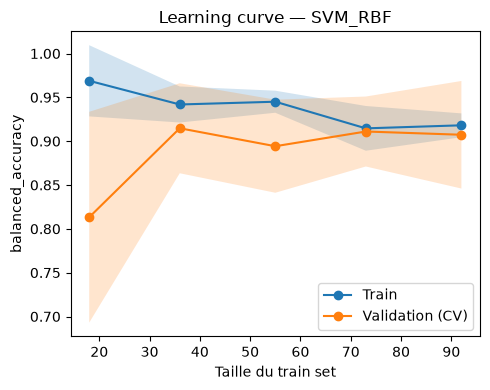


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300}
Meilleur score CV : 0.921 ±  0.038
Score sur test set : 0.941


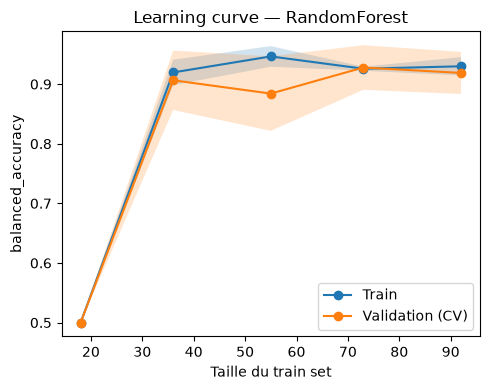


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.912 ±  0.045
Score sur test set : 0.918


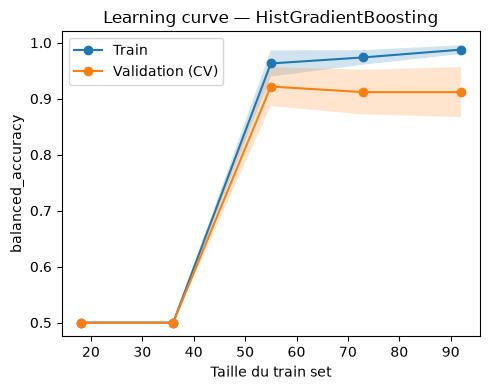


=== Comparaison des modèles ===
                      CV score    CV std  Test score
RandomForest          0.921049  0.037560    0.941176
HistGradientBoosting  0.911807  0.044725    0.918449
SVM_RBF               0.907343  0.061350    0.941176
LogisticRegression    0.899650  0.068594    0.911765

Meilleur modèle : RandomForest
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       0.92      1.00      0.96        22

    accuracy                           0.95        39
   macro avg       0.96      0.94      0.95        39
weighted avg       0.95      0.95      0.95        39



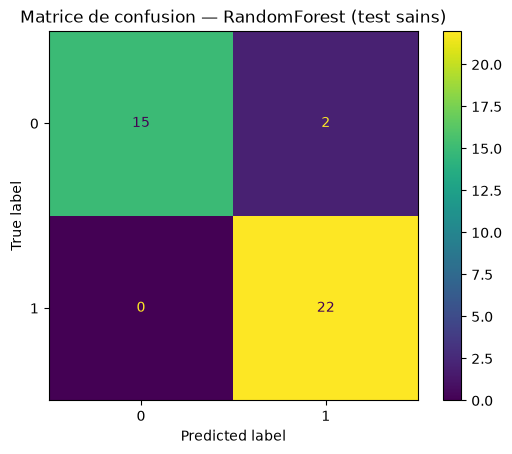

Meilleur modèle pour core_ax : RandomForest

========================= core_sz =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    55
1    99
Name: count, dtype: int64
Cluster 0: 55 participants (group 0: 55)
Cluster 1: 99 participants (group 0: 99)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.98 ±  0.026
Score sur test set : 0.96


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

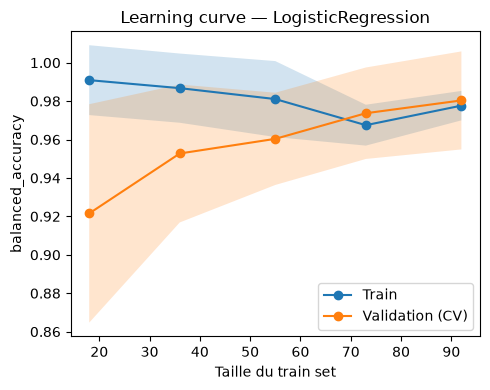


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 0.1}
Meilleur score CV : 0.98 ±  0.026
Score sur test set : 0.964


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

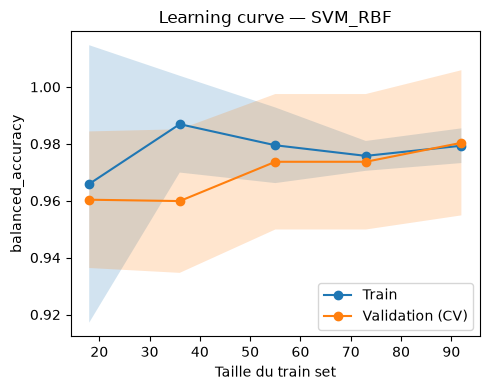


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
Meilleur score CV : 0.961 ±  0.023
Score sur test set : 0.929


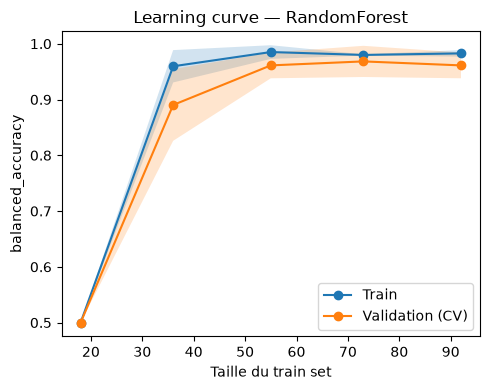


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.949 ±  0.042
Score sur test set : 0.929


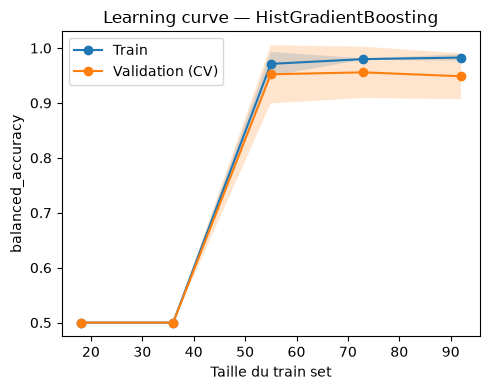


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.980357  0.025505    0.960000
SVM_RBF               0.980357  0.025505    0.964286
RandomForest          0.961190  0.023101    0.928571
HistGradientBoosting  0.948690  0.041844    0.928571

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        14
           1       1.00      0.92      0.96        25

    accuracy                           0.95        39
   macro avg       0.94      0.96      0.95        39
weighted avg       0.96      0.95      0.95        39



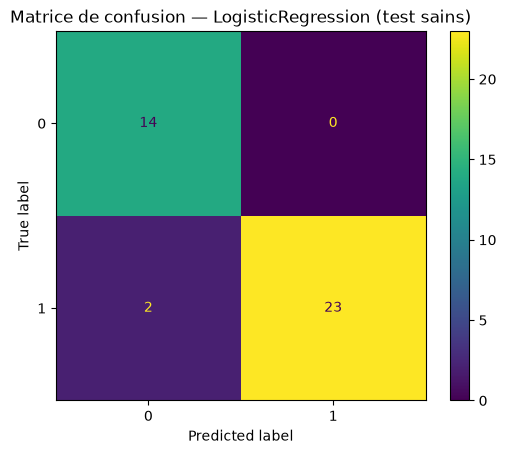

Meilleur modèle pour core_sz : LogisticRegression

========================= core_mdd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    104
1     50
Name: count, dtype: int64
Cluster 0: 104 participants (group 0: 104)
Cluster 1: 50 participants (group 0: 50)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.923 ±  0.064
Score sur test set : 0.923


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

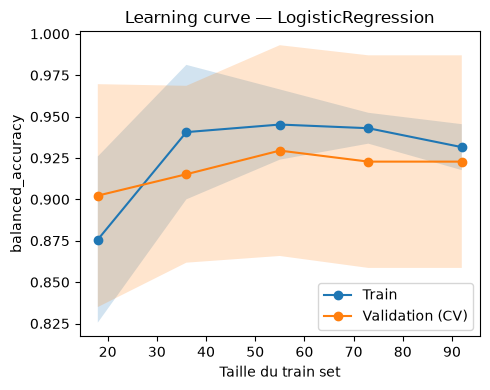


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.969 ±  0.028
Score sur test set : 0.962


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

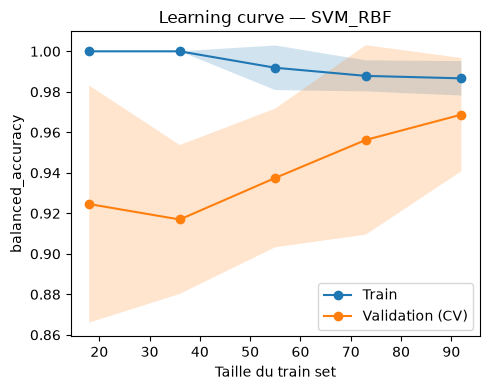


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
Meilleur score CV : 0.968 ±  0.048
Score sur test set : 0.962


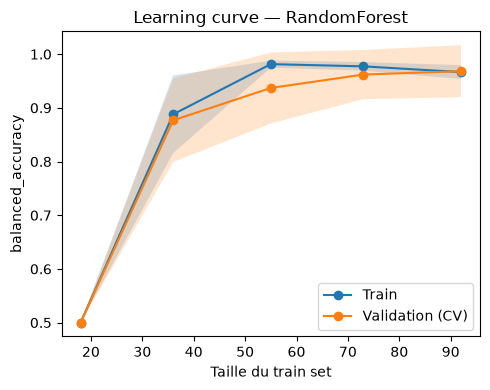


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.968 ±  0.048
Score sur test set : 0.962


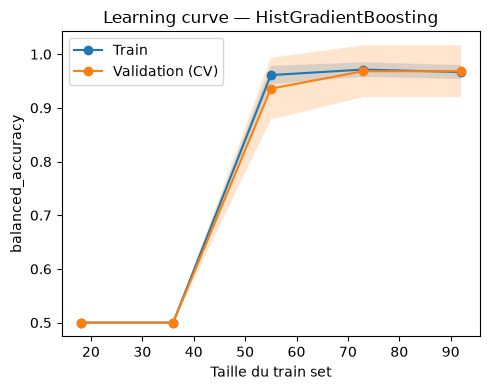


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.968750  0.027951    0.961538
RandomForest          0.968333  0.048419    0.961538
HistGradientBoosting  0.968333  0.048419    0.961538
LogisticRegression    0.922798  0.064215    0.923077

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.87      1.00      0.93        13

    accuracy                           0.95        39
   macro avg       0.93      0.96      0.94        39
weighted avg       0.96      0.95      0.95        39



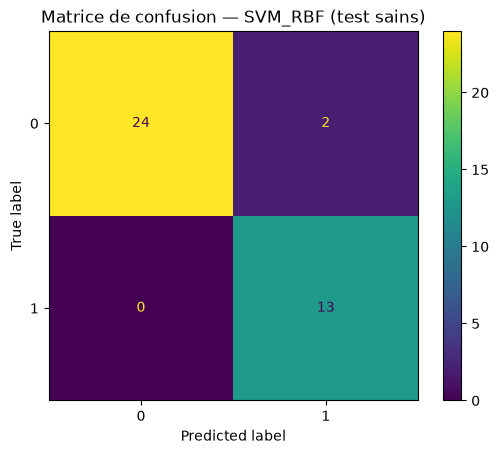

Meilleur modèle pour core_mdd : SVM_RBF

========================= core_man =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    74
1    80
Name: count, dtype: int64
Cluster 0: 74 participants (group 0: 74)
Cluster 1: 80 participants (group 0: 80)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 100, 'clf__penalty': 'l2'}
Meilleur score CV : 0.93 ±  0.021
Score sur test set : 0.947


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

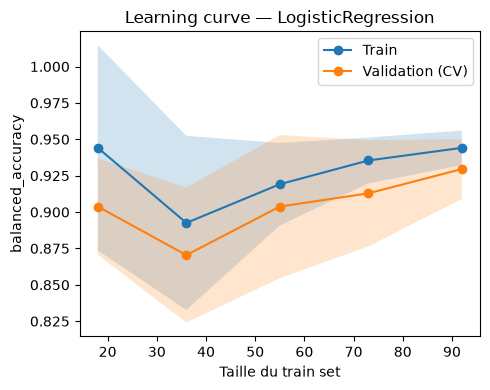


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 'scale'}
Meilleur score CV : 0.991 ±  0.018
Score sur test set : 1.0


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

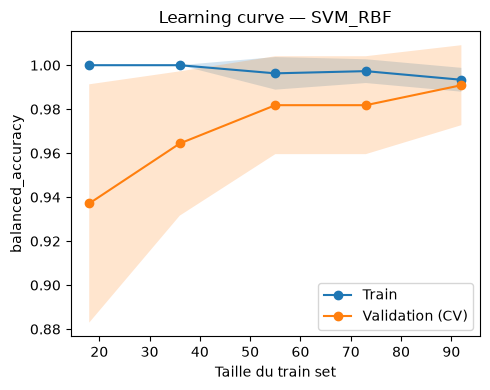


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.983 ±  0.021
Score sur test set : 1.0


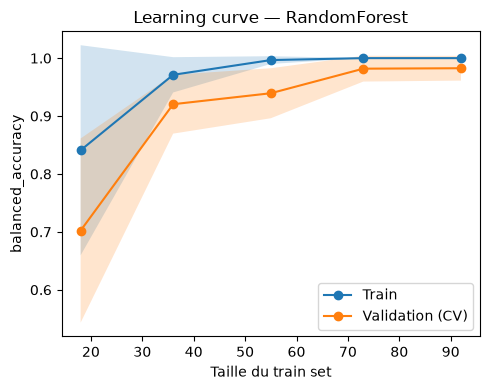


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.973 ±  0.022
Score sur test set : 1.0


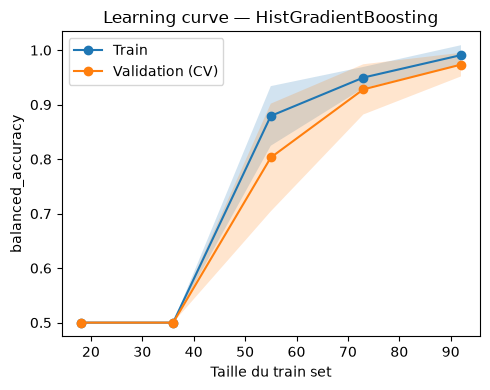


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.990909  0.018182    1.000000
RandomForest          0.982576  0.021374    1.000000
HistGradientBoosting  0.973485  0.021694    1.000000
LogisticRegression    0.929545  0.020553    0.947368

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        20

    accuracy                           1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39



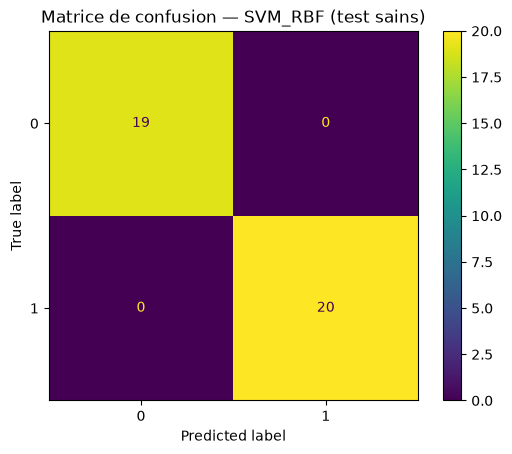

Meilleur modèle pour core_man : SVM_RBF

========================= core_ptsd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    62
1    92
Name: count, dtype: int64
Cluster 0: 62 participants (group 0: 62)
Cluster 1: 92 participants (group 0: 92)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.972 ±  0.024
Score sur test set : 0.969


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

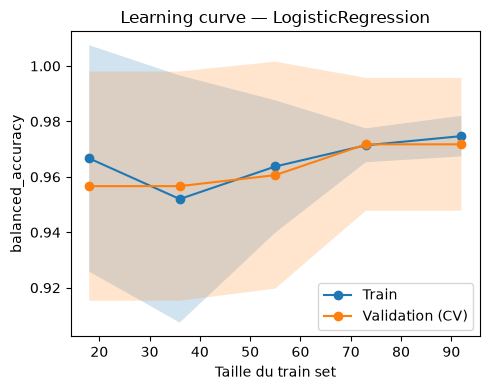


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 0.1}
Meilleur score CV : 0.972 ±  0.024
Score sur test set : 0.969


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

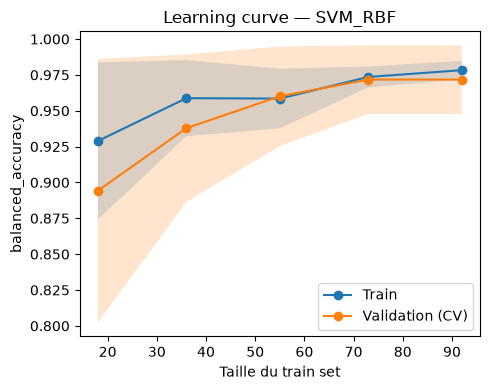


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.964 ±  0.034
Score sur test set : 0.969


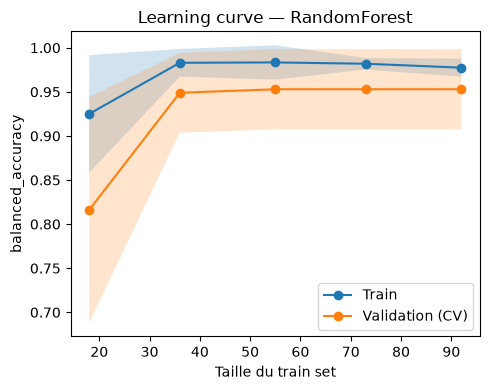


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.953 ±  0.046
Score sur test set : 0.969


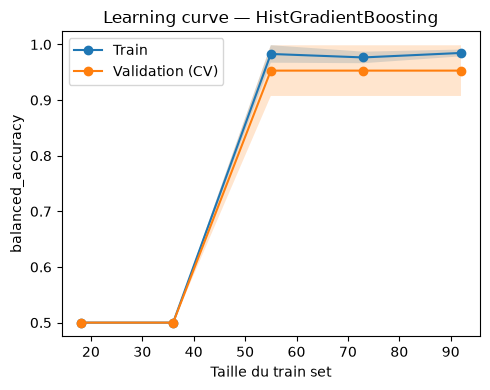


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.971746  0.023960     0.96875
SVM_RBF               0.971746  0.023960     0.96875
RandomForest          0.964054  0.033843     0.96875
HistGradientBoosting  0.952943  0.045551     0.96875

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.96      1.00      0.98        23

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39



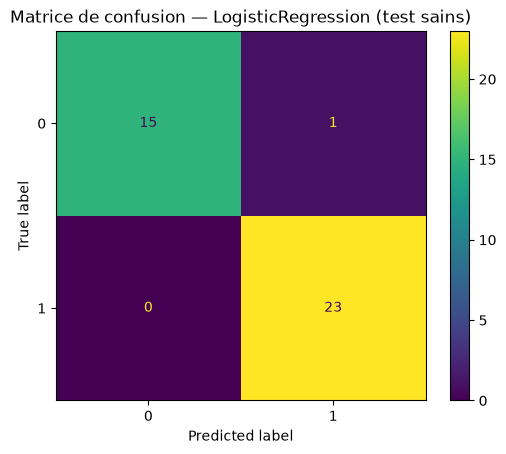

Meilleur modèle pour core_ptsd : LogisticRegression

========================= periph_ax =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    60
1    94
Name: count, dtype: int64
Cluster 0: 60 participants (group 0: 60)
Cluster 1: 94 participants (group 0: 94)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.956 ±  0.041
Score sur test set : 0.958


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

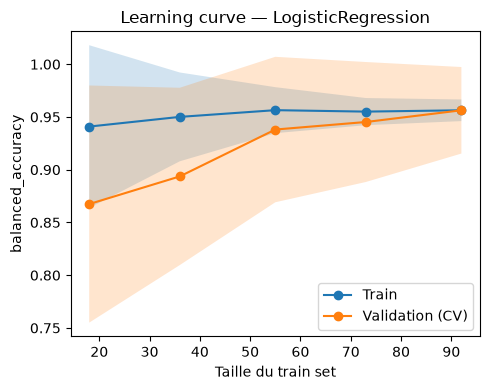


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 'scale'}
Meilleur score CV : 0.956 ±  0.041
Score sur test set : 0.958


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

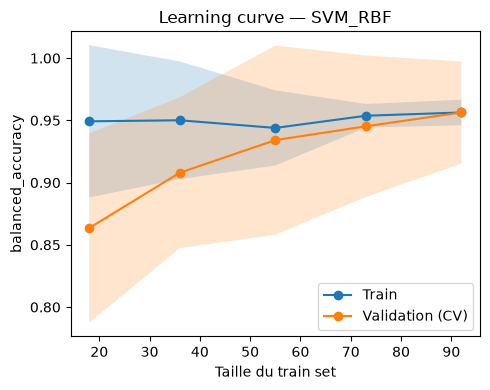


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
Meilleur score CV : 0.93 ±  0.094
Score sur test set : 0.958


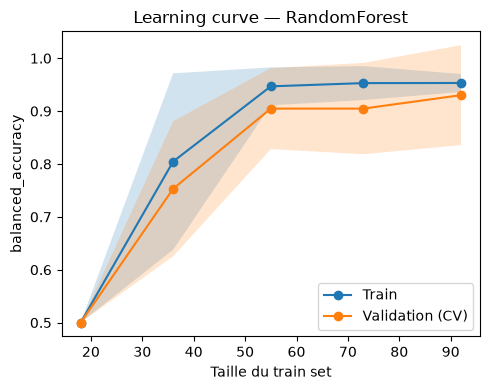


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.926 ±  0.076
Score sur test set : 0.925


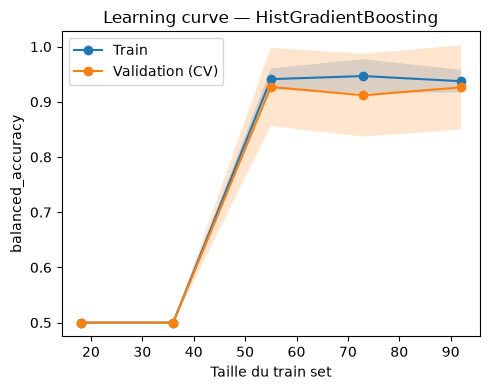


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.956349  0.041010    0.958333
SVM_RBF               0.956349  0.041010    0.958333
RandomForest          0.930159  0.094494    0.958333
HistGradientBoosting  0.926190  0.076356    0.925000

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.92      0.96        24

    accuracy                           0.95        39
   macro avg       0.94      0.96      0.95        39
weighted avg       0.95      0.95      0.95        39



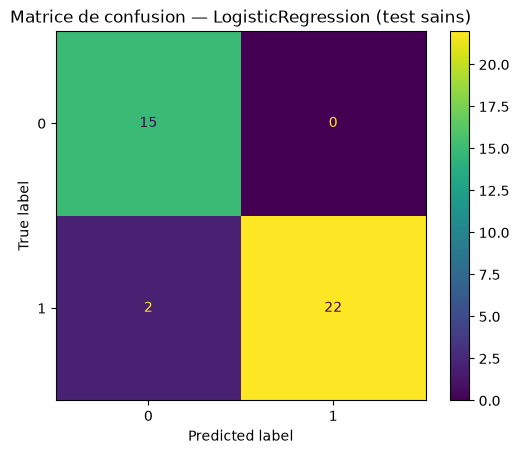

Meilleur modèle pour periph_ax : LogisticRegression

========================= periph_sz =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    64
1    90
Name: count, dtype: int64
Cluster 0: 64 participants (group 0: 64)
Cluster 1: 90 participants (group 0: 90)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.971 ±  0.037
Score sur test set : 0.947


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

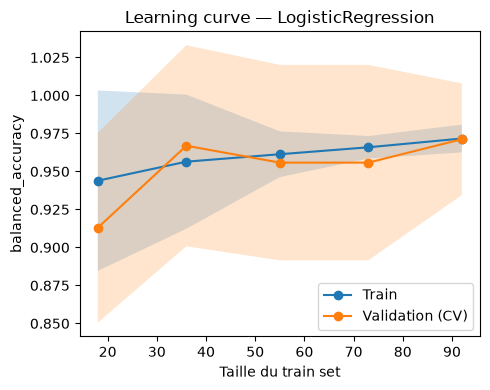


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 0.1}
Meilleur score CV : 0.971 ±  0.037
Score sur test set : 0.969


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

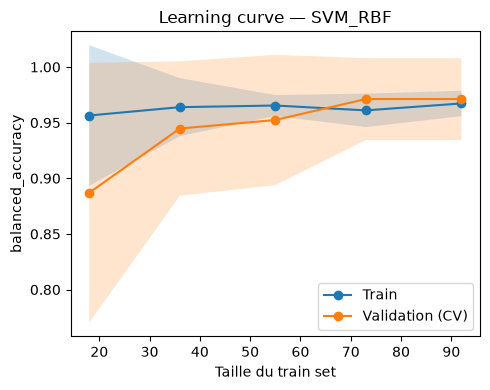


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.964 ±  0.05
Score sur test set : 0.969


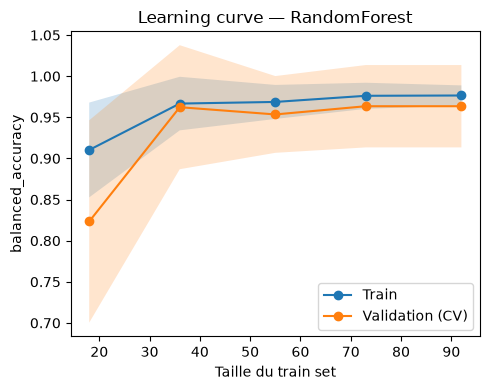


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.964 ±  0.05
Score sur test set : 0.969


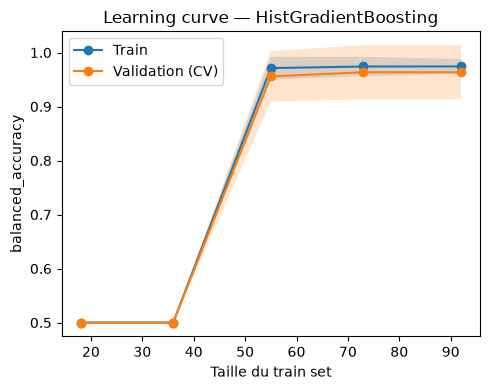


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.971197  0.036780    0.947011
SVM_RBF               0.971197  0.036780    0.968750
RandomForest          0.963504  0.050072    0.968750
HistGradientBoosting  0.963504  0.050072    0.968750

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.96      0.96      0.96        23

    accuracy                           0.95        39
   macro avg       0.95      0.95      0.95        39
weighted avg       0.95      0.95      0.95        39



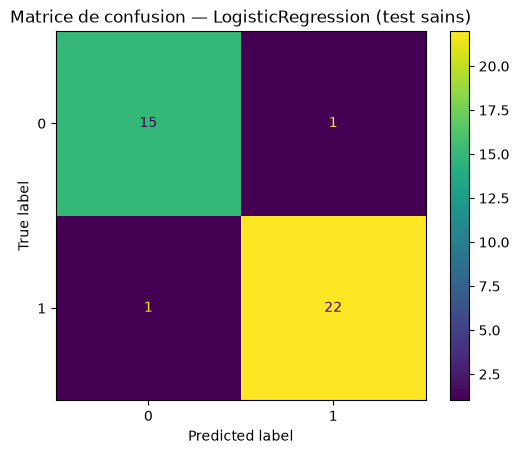

Meilleur modèle pour periph_sz : LogisticRegression

========================= periph_mdd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    88
1    66
Name: count, dtype: int64
Cluster 0: 88 participants (group 0: 88)
Cluster 1: 66 participants (group 0: 66)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.926 ±  0.048
Score sur test set : 0.977


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

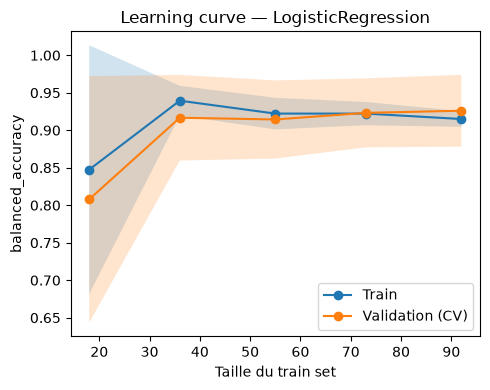


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.931 ±  0.043
Score sur test set : 1.0


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

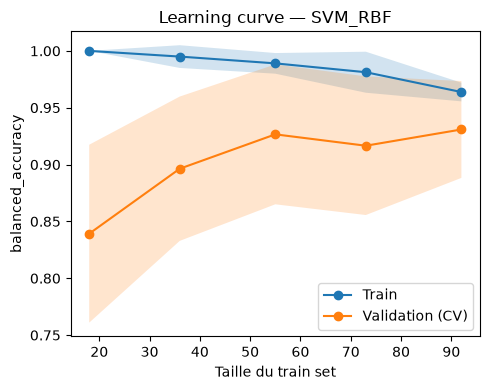


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 500}
Meilleur score CV : 0.931 ±  0.043
Score sur test set : 1.0


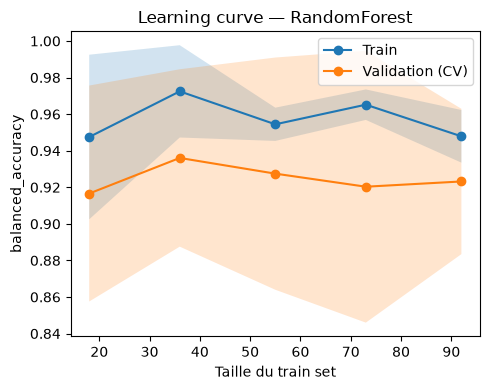


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.924 ±  0.051
Score sur test set : 1.0


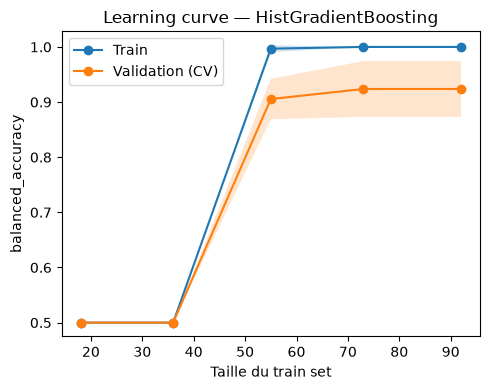


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.930879  0.042592    1.000000
RandomForest          0.930879  0.042592    1.000000
LogisticRegression    0.926044  0.047912    0.977273
HistGradientBoosting  0.923736  0.050610    1.000000

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        17

    accuracy                           1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39



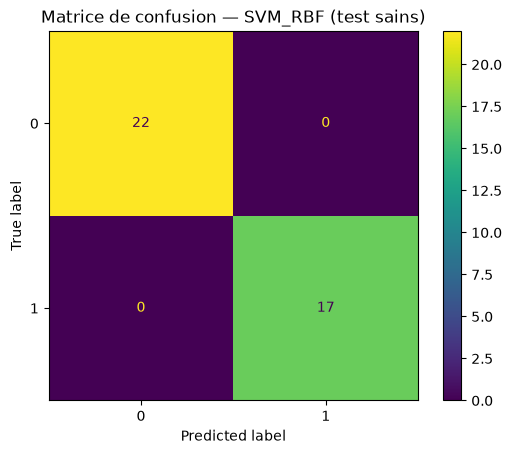

Meilleur modèle pour periph_mdd : SVM_RBF

========================= periph_man =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    92
1    62
Name: count, dtype: int64
Cluster 0: 92 participants (group 0: 92)
Cluster 1: 62 participants (group 0: 62)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.975 ±  0.022
Score sur test set : 0.947


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

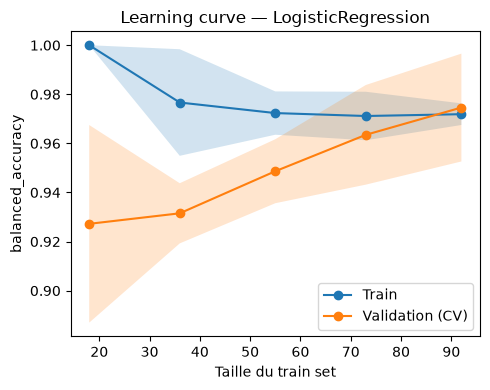


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 1}
Meilleur score CV : 0.985 ±  0.018
Score sur test set : 0.916


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

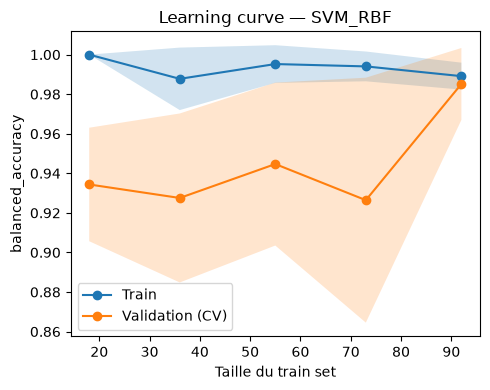


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.957 ±  0.022
Score sur test set : 0.938


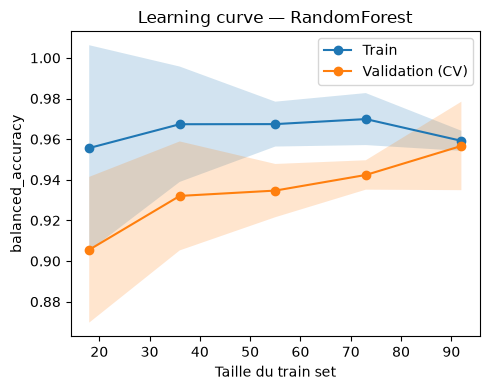


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.982 ±  0.023
Score sur test set : 0.906


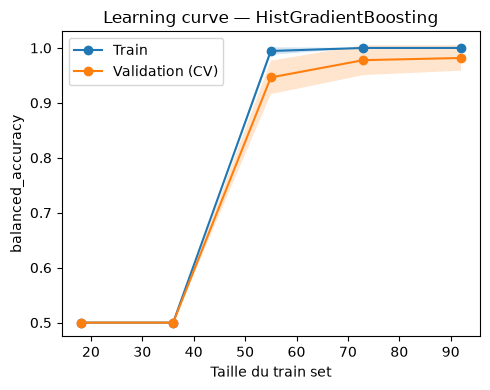


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.985165  0.018190    0.915761
HistGradientBoosting  0.981746  0.023220    0.906250
LogisticRegression    0.974603  0.021966    0.947011
RandomForest          0.956667  0.021773    0.937500

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        23
           1       0.93      0.88      0.90        16

    accuracy                           0.92        39
   macro avg       0.93      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39



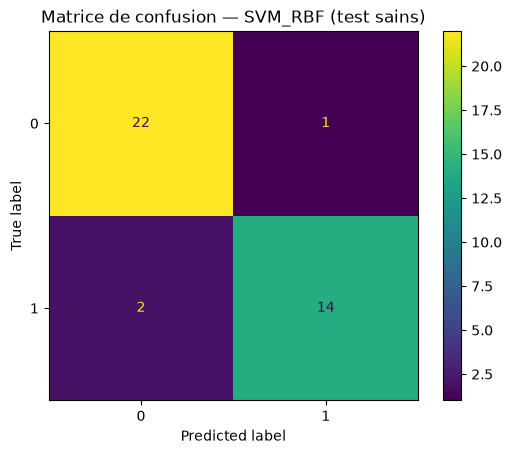

Meilleur modèle pour periph_man : SVM_RBF

========================= periph_ptsd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    93
1    61
Name: count, dtype: int64
Cluster 0: 93 participants (group 0: 93)
Cluster 1: 61 participants (group 0: 61)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.971 ±  0.037
Score sur test set : 0.892


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

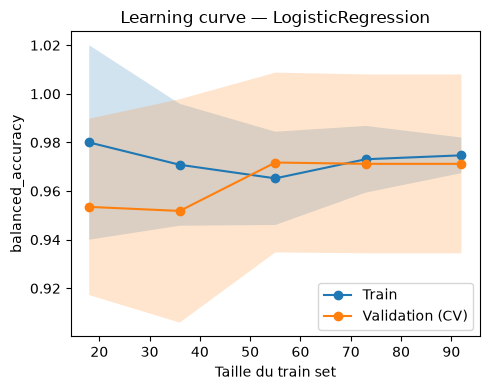


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.972 ±  0.037
Score sur test set : 0.879


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

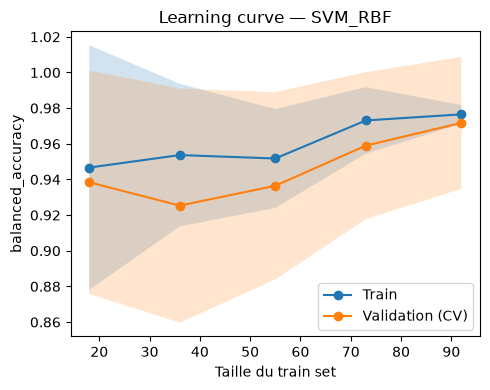


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.975 ±  0.035
Score sur test set : 0.913


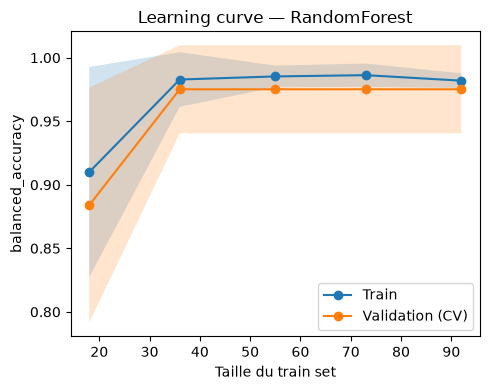


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.975 ±  0.035
Score sur test set : 0.913


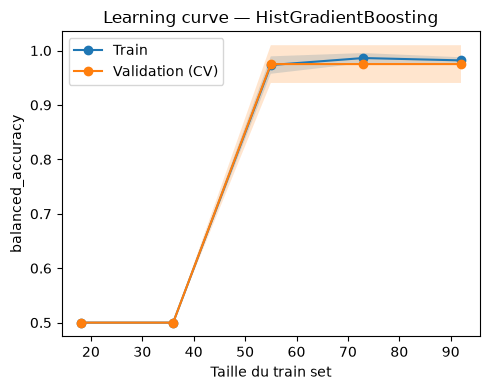


=== Comparaison des modèles ===
                      CV score    CV std  Test score
HistGradientBoosting  0.975165  0.034690    0.912500
RandomForest          0.975165  0.034690    0.912500
SVM_RBF               0.971746  0.036983    0.879167
LogisticRegression    0.971197  0.036780    0.891667

Meilleur modèle : HistGradientBoosting
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        24
           1       0.93      0.87      0.90        15

    accuracy                           0.92        39
   macro avg       0.92      0.91      0.92        39
weighted avg       0.92      0.92      0.92        39



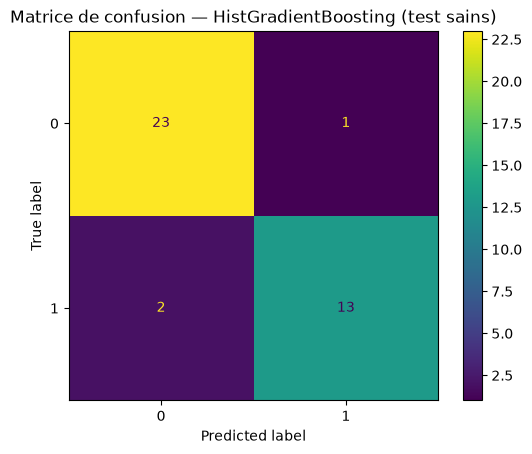

Meilleur modèle pour periph_ptsd : HistGradientBoosting


In [41]:
from umap_clustering import run_umap_clustering
from machinelearning import train_and_compare_classifiers, apply_to_patients

resultats_sous_echelles = {}

for nom, df_sains in sous_echelles_red.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    # UMAP + KMeans fit sur TOUS les participants sains 
    result = run_umap_clustering(
        df_sains, n_clusters=2, random_state=42, group=group, show=False,
    )

    # Split train/test des sains SUR les projections/labels déjà calculés (pour le classifieur)
    X_all = result.proj_2d
    y_all = result.clusters
    idx_all = df_sains.index

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_all, y_all, idx_all,
        test_size=0.25,
        random_state=42,
        stratify=y_all,
    )

    # Entraîner et comparer les classifieurs
    results, summary, best_model_name, best_model = train_and_compare_classifiers(
        X_train, y_train, X_test, y_test,
        scoring="balanced_accuracy",
        plot_curves=True,
    )

    # Application aux patients (transform UMAP + predict, jamais refit)
    df_patients_pred = apply_to_patients(
        best_model=best_model,
        umap_model=result.umap_2d_model,
        df_red_pd=df_patients,
    )

    resultats_sous_echelles[nom] = {
        "result": result,             
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "idx_train": idx_train, "idx_test": idx_test,
        "results": results,
        "summary": summary,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "df_patients_pred": df_patients_pred,
    }

    print(f"Meilleur modèle pour {nom} : {best_model_name}")

clairement overfit le mod ne foncctionne pas : surtout pour core manie et periph mdd. 

# Récap des meilleurs modeles trouvés pour chq sous echelle

In [42]:
recap = []
for nom, r in resultats_sous_echelles.items():
    best_row = r["summary"].loc[r["best_model_name"]]
    patient_counts = r["df_patients_pred"]["predicted_cluster"].value_counts().sort_index()
    recap.append({
        "sous_echelle": nom,
        "best_model": r["best_model_name"],
        "cv_score": round(best_row["CV score"], 3),
        "test_score": round(best_row["Test score"], 3),
        "patients_cluster_0": patient_counts.get(0, 0),
        "patients_cluster_1": patient_counts.get(1, 0),
    })

df_recap = pd.DataFrame(recap).sort_values("test_score", ascending=False)
df_recap

,sous_echelle,best_model,cv_score,test_score,patients_cluster_0,patients_cluster_1
7,periph_mdd,SVM_RBF,0.931,1.000,17,14
3,core_man,SVM_RBF,0.991,1.000,13,18
4,core_ptsd,LogisticRegression,0.972,0.969,18,13
2,core_mdd,SVM_RBF,0.969,0.962,12,19
1,core_sz,LogisticRegression,0.980,0.960,16,15
5,periph_ax,LogisticRegression,0.956,0.958,19,12
6,periph_sz,LogisticRegression,0.971,0.947,17,14
0,core_ax,RandomForest,0.921,0.941,19,12
8,periph_man,SVM_RBF,0.985,0.916,12,19
9,periph_ptsd,HistGradientBoosting,0.975,0.913,13,18


# Visualisation de la classification des participants avec diag dans l'espace UMAP

In [43]:
import pandas as pd
import plotly.express as px

for nom, r in resultats_sous_echelles.items():
    result = r["result"]
    df_patients_pred = r["df_patients_pred"]
    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    X_patients_umap = result.umap_2d_model.transform(df_patients.values)

    hover_train = [f"Participant {i}" for i in r["idx_train"]]
    hover_test  = [f"Participant {i}" for i in r["idx_test"]]
    hover_diag  = [f"Participant {i}" for i in df_patients.index]

    df_plot = pd.concat([
        pd.DataFrame({
            "x": r["X_train"][:, 0], "y": r["X_train"][:, 1],
            "cluster": r["y_train"].astype(str),
            "type": "Sains (train)",
            "participant": hover_train,
        }),
        pd.DataFrame({
            "x": r["X_test"][:, 0], "y": r["X_test"][:, 1],
            "cluster": r["y_test"].astype(str),
            "type": "Sains (test)",
            "participant": hover_test,
        }),
        pd.DataFrame({
            "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
            "cluster": df_patients_pred["predicted_cluster"].astype(str),
            "type": "Diag",
            "participant": hover_diag,
        }),
    ], ignore_index=True)

    fig = px.scatter(
        df_plot, x="x", y="y",
        color="cluster", symbol="type",
        color_discrete_map={"0": "#A777F1", "1": "#FC6955"},
        symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
        opacity=0.7,
        hover_name="participant",
        title=f"{nom} — Sains (train/test) et patients projetés dans l'espace UMAP (fit sur tous les sains)",
    )

    for trace in fig.data:
        if "Diag" in trace.name:
            trace.marker.line = dict(width=1, color="black")

    fig.show(renderer="browser")

# Regardons si le profil des participants avec diag mis dans le cluster 1 correspond à leur diag en fonction des sous echelles

In [44]:
col_name = df_PD.columns[18]
print(f"Colonne diag : {col_name}")

diag = df_PD[col_name]   
repartition_patients = {}

for nom, r in resultats_sous_echelles.items():
    df_patients_pred = r["df_patients_pred"]

    cluster_0_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 0].index
    cluster_1_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 1].index

    cluster_0 = list(zip(cluster_0_idx, diag.reindex(cluster_0_idx)))
    cluster_1 = list(zip(cluster_1_idx, diag.reindex(cluster_1_idx)))

    repartition_patients[nom] = {
        "cluster_0": cluster_0,
        "cluster_1": cluster_1,
    }

    print(f"\n{'='*25} {nom} {'='*25}")
    print(f"Cluster 0 ({len(cluster_0)} patients) :")
    for participant, d in cluster_0:
        print(f"  Participant {participant} → {d}")
    print(f"Cluster 1 ({len(cluster_1)} patients) :")
    for participant, d in cluster_1:
        print(f"  Participant {participant} → {d}")

Colonne diag : Si oui, lequel (lesquels) ? 

========================= core_ax =========================
Cluster 0 (19 patients) :
  Participant 4 → Trouble anxieux
  Participant 13 → Dépression
  Participant 20 → TROUBLE BIPOLAIRE TYPE 1
  Participant 28 → épisode dépressif caractérisé
  Participant 79 → Tendance depressive
  Participant 113 → Dépression
  Participant 140 → Dépression, anxiété, TdAH
  Participant 149 → Diagnostic d’un trouble anxieux et généralisé
  Participant 176 → TSA, TDAH, TDI, bipolarité type 1
  Participant 178 → TAG
  Participant 182 → Dépression
  Participant 195 → Syndrome anxio dépressif
  Participant 209 → Dépression
  Participant 242 → Episode depressif modéré
  Participant 247 → TDAH et TAG
  Participant 251 → Bipolarité
  Participant 265 → Dépression + Anxiété
  Participant 272 → Trouble anxieux généralisé, trouble anxieux social et trouble anxieux de performance
  Participant 290 → Trouble anxieux généralisé, anxiété sociale, stress post traumatique et

Finalement le cluster 0 ou 1 change : le + ou - symptomatique selon les df. Globalement apres analyse: les items spé de la /// sont représentatifs de ... 
Attention, les modèles ont surappris, on a pas assez d'echantillon et encore moins de patients! 

# SFS - Sequential Feature Selection - backward

Boucle pour chaque type de patho (sauf comorbidité qui ne faisait pas partie de l'echelle) : 
Par exemple, on prend les patients MDD qu'on renomme "1" et tous les controles "0", sur les 40 items. On entraine un classifier sur tout (split train/test sur les 2 groupes )avec cv = stratifiedKfold car groupes non equilibrés. Puis on rgerade si classifier capable de classer 0 et 1. Va me sortir les items spé des patients MDD avec le SFS. A comparer avec ceux établis par Northoff 

In [45]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, classification_report

# Groupes diagnostiques 
sz    = df_PD.iloc[[10]]
man   = df_PD.iloc[[4, 21, 22, 26, 29, 30]]
ax    = df_PD.iloc[[1, 12, 13, 15, 24]]
dep   = df_PD.iloc[[2, 3, 5, 6, 7, 8, 9, 16, 18, 19, 28]]
comor = df_PD.iloc[[0, 11, 14, 17, 20, 23, 25, 27]]

# Mapping des noms des sous-échelle -> groupe patients ciblé + items core/periph prédéfinis
diag_map = {
    "mdd":  {"idx_target": dep.index,  "items_core": items_core_md, "items_periph": items_per_md},
    "sz":   {"idx_target": sz.index,   "items_core": items_core_sz, "items_periph": items_per_sz},
    "man":  {"idx_target": man.index,  "items_core": items_core_ma, "items_periph": items_per_ma},
    "ax":   {"idx_target": ax.index,   "items_core": items_core_an, "items_periph": items_per_an},
}

items_40 = [f"TSQ{i}" for i in range(1, 41)]
df_healthy_40 = df_TSQ[items_40]   

resultats_sfs_diag = {}

for nom, cfg in diag_map.items():
    print(f"\n{'='*25} {nom.upper()} {'='*25}")

    idx_target = cfg["idx_target"]
    idx_common = df_TSQ_PD.index.intersection(idx_target)
    df_patients_target = df_TSQ_PD.loc[idx_common, items_40]

    print(f"{len(df_patients_target)} patients '{nom}' trouvés / {len(idx_target)} attendus")

    if len(df_patients_target) < 5:
        print(f"Trop peu de patients '{nom}' ({len(df_patients_target)}) pour un split fiable, on passe.")
        continue

    # Dataset binaire : 0 = sain, 1 = diag ciblé, sur les 40 items
    X_full = pd.concat([df_healthy_40, df_patients_target], axis=0)
    y_full = np.array([0] * len(df_healthy_40) + [1] * len(df_patients_target))
    idx_full = X_full.index

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_full, y_full, idx_full,
        test_size=0.25, random_state=42, stratify=y_full,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=5,
        class_weight="balanced", random_state=42,
    )

    baseline_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="balanced_accuracy")
    print(f"Score CV baseline (40 items) : {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")

    sfs = SequentialFeatureSelector(
        clf, direction="backward", n_features_to_select="auto",#essayer de changer 5 par ex
        tol=-0.005, scoring="balanced_accuracy", cv=cv, n_jobs=-1,
    )
    sfs.fit(X_train, y_train)

    selected_items = list(X_train.columns[sfs.get_support()])
    print(f"Items sélectionnés par SFS ({len(selected_items)}/40) :", selected_items)

    clf.fit(X_train[selected_items], y_train)
    y_pred = clf.predict(X_test[selected_items])
    test_score = balanced_accuracy_score(y_test, y_pred)
    print(f"Score test (items SFS) : {test_score:.3f}")
    print(classification_report(y_test, y_pred))

    # Comparaison avec les items core/periphery prédéfinis par Northoff
    items_core = set(cfg["items_core"])
    items_periph = set(cfg["items_periph"])
    selected_set = set(selected_items)

    overlap_core = selected_set & items_core
    overlap_periph = selected_set & items_periph
    overlap_neither = selected_set - items_core - items_periph

    print(f"Overlap avec items_core_{nom} : {sorted(overlap_core)} ({len(overlap_core)}/{len(items_core)})")
    print(f"Overlap avec items_periph_{nom} : {sorted(overlap_periph)} ({len(overlap_periph)}/{len(items_periph)})")
    print(f"Items SFS hors core/periph prédéfinis : {sorted(overlap_neither)}")

    resultats_sfs_diag[nom] = {
        "n_patients": len(df_patients_target),
        "selected_items": selected_items,
        "baseline_cv_score": baseline_scores.mean(),
        "test_score_sfs": test_score,
        "overlap_core": overlap_core,
        "overlap_periph": overlap_periph,
        "idx_train": idx_train, "idx_test": idx_test,
        "sfs": sfs, "clf": clf,
    }


========================= MDD =========================
11 patients 'mdd' trouvés / 11 attendus
Score CV baseline (40 items) : 0.535 ± 0.141
Items sélectionnés par SFS (37/40) : ['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ5', 'TSQ6', 'TSQ7', 'TSQ9', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ22', 'TSQ23', 'TSQ24', 'TSQ25', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ39', 'TSQ40']
Score test (items SFS) : 0.667
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        39
           1       1.00      0.33      0.50         3

    accuracy                           0.95        42
   macro avg       0.98      0.67      0.74        42
weighted avg       0.95      0.95      0.94        42

Overlap avec items_core_mdd : ['TSQ14', 'TSQ25', 'TSQ28', 'TSQ29', 'TSQ36', 'TSQ9'] (6/7)
Overlap avec items_periph_mdd : ['TSQ1', 'TSQ12

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Score CV baseline (40 items) : 0.552 ± 0.184


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_sp

Items sélectionnés par SFS (8/40) : ['TSQ4', 'TSQ8', 'TSQ18', 'TSQ29', 'TSQ31', 'TSQ33', 'TSQ37', 'TSQ40']
Score test (items SFS) : 0.487
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        39
           1       0.00      0.00      0.00         1

    accuracy                           0.95        40
   macro avg       0.49      0.49      0.49        40
weighted avg       0.95      0.95      0.95        40

Overlap avec items_core_ax : ['TSQ33', 'TSQ37'] (2/14)
Overlap avec items_periph_ax : ['TSQ18'] (1/9)
Items SFS hors core/periph prédéfinis : ['TSQ29', 'TSQ31', 'TSQ4', 'TSQ40', 'TSQ8']


n'affichera pas pour les sz ni ptsd par exemple car trop peu de patients: ne sert a rien de split train/test

In [46]:
recap_sfs_diag = pd.DataFrame({
    nom: {
        "n_patients": r["n_patients"],
        "n_items_selected": len(r["selected_items"]),
        "baseline_cv": round(r["baseline_cv_score"], 3),
        "test_score": round(r["test_score_sfs"], 3),
        "n_overlap_core": len(r["overlap_core"]),
        "n_overlap_periph": len(r["overlap_periph"]),
    }
    for nom, r in resultats_sfs_diag.items()
}).T

recap_sfs_diag

,n_patients,n_items_selected,baseline_cv,test_score,n_overlap_core,n_overlap_periph
mdd,11.0,37.0,0.535,0.667,6.0,10.0
man,6.0,20.0,0.483,0.974,3.0,5.0
ax,5.0,8.0,0.552,0.487,2.0,1.0


# RFECV - Recursive feature elimination with cross-validation to select features.

In [47]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    57
1    97
Name: count, dtype: int64
Cluster 0: 57 participants (group 0: 57)
Cluster 1: 97 participants (group 0: 97)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.951 ±  0.031
Score sur test set : 0.873


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

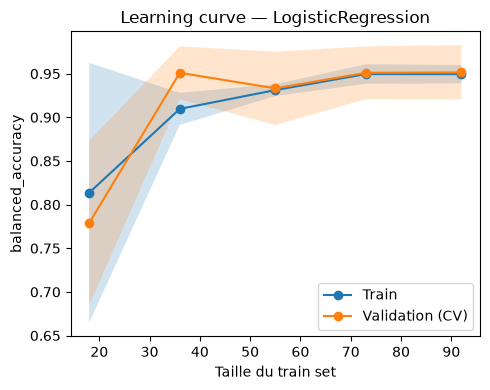


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 1}
Meilleur score CV : 0.964 ±  0.02
Score sur test set : 0.893


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

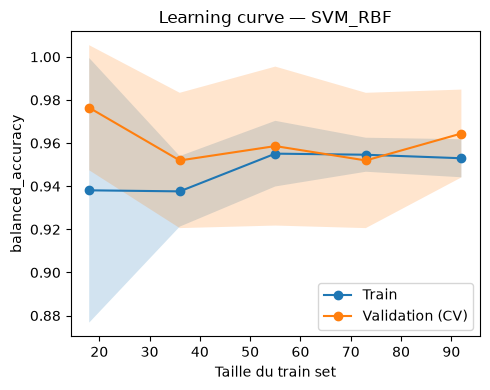


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.958 ±  0.024
Score sur test set : 0.929


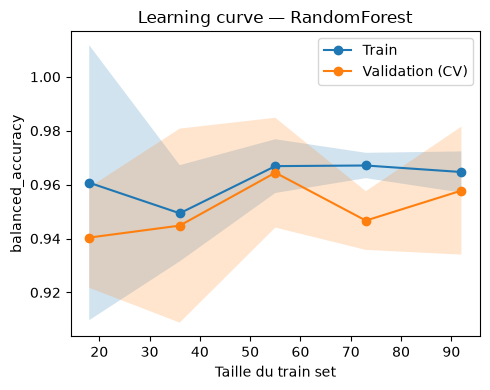


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.947 ±  0.037
Score sur test set : 0.929


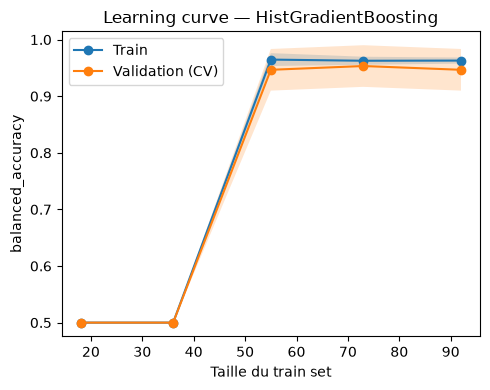


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.964444  0.020367    0.892857
RandomForest          0.957778  0.023727    0.928571
LogisticRegression    0.951468  0.031163    0.872857
HistGradientBoosting  0.946667  0.036784    0.928571

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.89      1.00      0.94        25

    accuracy                           0.92        39
   macro avg       0.95      0.89      0.91        39
weighted avg       0.93      0.92      0.92        39



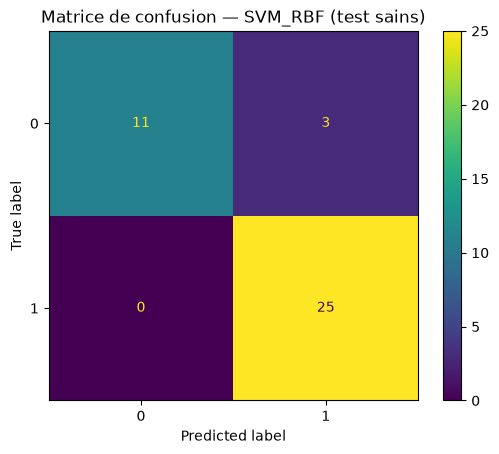

[UMAP 2D] Meilleur modèle : SVM_RBF
                      CV score    CV std  Test score
SVM_RBF               0.964444  0.020367    0.892857
RandomForest          0.957778  0.023727    0.928571
LogisticRegression    0.951468  0.031163    0.872857
HistGradientBoosting  0.946667  0.036784    0.928571
Nombre optimal d'items : 40
Score CV (balanced accuracy) : 0.963
Score test (items sélectionnés) : 0.964

Items sélectionnés, par importance décroissante :
TSQ39    0.077197
TSQ26    0.070167
TSQ15    0.059839
TSQ36    0.059194
TSQ19    0.051942
TSQ34    0.046147
TSQ22    0.045942
TSQ10    0.040890
TSQ25    0.038385
TSQ38    0.037337
TSQ33    0.035872
TSQ3     0.032946
TSQ1     0.029796
TSQ9     0.029644
TSQ35    0.029152
TSQ30    0.027052
TSQ32    0.025500
TSQ24    0.024923
TSQ8     0.024265
TSQ5     0.024014
TSQ28    0.022234
TSQ37    0.021889
TSQ20    0.019434
TSQ18    0.019046
TSQ13    0.016276
TSQ40    0.012361
TSQ17    0.011938
TSQ31    0.010749
TSQ27    0.008833
TSQ16    0.006784
TSQ

In [48]:
import rfecv as prg

resultats_analyse = prg.run_full_analysis(
    df_PD=df_PD,
    df_sains_40=df_TSQ,
    df_red_sains=df_red_sains,
    df_pd_40=df_TSQ_PD,
    df_red_pd=df_red_pd,
    group=group,
    items_core_sz=items_core_sz,
    items_core_ma=items_core_ma,
    items_core_an=items_core_an,
    items_core_md=items_core_md,
)
recaps = resultats_analyse["recaps"]